# 1H — Hollow cabinet geometry and neutron/gamma OpenMC runs

This notebook is the common transport notebook for the documented
asymmetric hollow cabinet model. It replaces the proposed cabinet-void
sensitivity study. Both f1/y walls and the front (+x) f2 wall contain the
documented 5 cm air layer; only the rear (-x) f2 wall remains solid.

From the free cabinet cavity towards the outside, the adopted layers are

$$
\mathrm{rear\ f2/(-x)}:\quad 15\ \mathrm{cm\ solid\ steel},
$$

$$
\mathrm{front\ f2/(+x)}:\quad
2\ \mathrm{cm\ steel}+5\ \mathrm{cm\ air}+8\ \mathrm{cm\ steel}
=15\ \mathrm{cm},
$$

$$
\mathrm{both\ f1/y\ walls}:\quad
2\ \mathrm{cm\ steel}+5\ \mathrm{cm\ air}+6\ \mathrm{cm\ steel}
=13\ \mathrm{cm}.
$$

The bottom f3 layer remains 25 cm of solid steel and the top f4 layer
remains 12 cm of solid steel. The outer cabinet dimensions, paraffin,
source capsule, rods, sample tubes, lead bricks, surrounding air, source
record, experimental date, P1–P5 scan distances, and all other physics
assumptions are retained.

The notebook performs two independent fixed-source transports:

- neutron transport, normalized per emitted source neutron and then scaled
  with the decay-corrected source-specific neutron emission;
- photon transport, normalized per emitted source photon and then scaled
  with the ALPHANSO total gamma-to-neutron yield ratio.

Neutron and gamma flux are **not added**, because they count different
particle species. Notebook `2H_Hollow_cabinet_unified.ipynb` will convert
them independently to AP dose rate before forming a total.


# 1) Setup, fixed geometry choice, and run controls

Set `RUN_NEUTRON_OPENMC` and `RUN_GAMMA_OPENMC` to `True` when the
production calculations are to be run. With a flag set to `False`, a
complete existing statepoint is reused if present; otherwise that result
section is skipped without fabricating data.

The photon workflow retains the reviewed two-group LND 712 CellFilter
geometry, MAGIC weight windows for the 60-point group, and the separate
analog calculation for the single overlapping placement. The latest
configured group-1 maximum is 800 batches.


In [5]:
from pathlib import Path
import importlib
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

import openmc
import ambe_base_model_f1_sides_and_front_f2_hollow as hollow_model_module

try:
    from IPython.display import display
except ImportError:
    def display(*objects):
        for object_to_display in objects:
            print(object_to_display)

importlib.reload(hollow_model_module)

EXPECTED_HOLLOW_MODEL_REVISION = (
    "F1_SIDES_AND_FRONT_F2_HOLLOW_2026-08-14"
)
actual_model_revision = getattr(
    hollow_model_module,
    "HOLLOW_MODEL_REVISION",
    None,
)
if actual_model_revision != EXPECTED_HOLLOW_MODEL_REVISION:
    raise RuntimeError(
        "Incorrect hollow-model module revision: "
        f"expected {EXPECTED_HOLLOW_MODEL_REVISION!r}, "
        f"found {actual_model_revision!r} in "
        f"{hollow_model_module.__file__}."
    )

BASE_DIR = Path.cwd().resolve()
H1_OUTPUT_DIR = (
    BASE_DIR / "H1_f1_sides_and_front_f2_hollow_transport_outputs"
)
GEOMETRY_OUTPUT_DIR = H1_OUTPUT_DIR / "geometry"
GEOMETRY_FIGURE_DIR = GEOMETRY_OUTPUT_DIR / "figures"
GEOMETRY_TABLE_DIR = GEOMETRY_OUTPUT_DIR / "tables"
GEOMETRY_XML_DIR = GEOMETRY_OUTPUT_DIR / "xml"
NEUTRON_OUTPUT_DIR = H1_OUTPUT_DIR / "neutron"
NEUTRON_TABLE_DIR = NEUTRON_OUTPUT_DIR / "tables"
NEUTRON_FIGURE_DIR = NEUTRON_OUTPUT_DIR / "figures"
NEUTRON_METADATA_DIR = NEUTRON_OUTPUT_DIR / "metadata"
NEUTRON_RUN_DIR = NEUTRON_OUTPUT_DIR / "openmc_run"
GAMMA_OUTPUT_DIR = H1_OUTPUT_DIR / "gamma"
GAMMA_TABLE_DIR = GAMMA_OUTPUT_DIR / "tables"
GAMMA_FIGURE_DIR = GAMMA_OUTPUT_DIR / "figures"
GAMMA_METADATA_DIR = GAMMA_OUTPUT_DIR / "metadata"
GAMMA_RUN_DIR = GAMMA_OUTPUT_DIR / "openmc_runs"
ROOT_TABLE_DIR = H1_OUTPUT_DIR / "tables"
ROOT_FIGURE_DIR = H1_OUTPUT_DIR / "figures"
ROOT_METADATA_DIR = H1_OUTPUT_DIR / "metadata"

for directory in (
    H1_OUTPUT_DIR,
    GEOMETRY_FIGURE_DIR,
    GEOMETRY_TABLE_DIR,
    GEOMETRY_XML_DIR,
    NEUTRON_TABLE_DIR,
    NEUTRON_FIGURE_DIR,
    NEUTRON_METADATA_DIR,
    NEUTRON_RUN_DIR,
    GAMMA_TABLE_DIR,
    GAMMA_FIGURE_DIR,
    GAMMA_METADATA_DIR,
    GAMMA_RUN_DIR,
    ROOT_TABLE_DIR,
    ROOT_FIGURE_DIR,
    ROOT_METADATA_DIR,
):
    directory.mkdir(parents=True, exist_ok=True)

EXPERIMENT_DATE = "2026-03-15"
RUN_NEUTRON_OPENMC = True
RUN_GAMMA_OPENMC = True

NEUTRON_RUN_BATCHES = 200
NEUTRON_PARTICLES_PER_BATCH = 100_000

HOLLOW_CONFIG = hollow_model_module.normalize_cabinet_config(
    hollow_model_module.MEASURED_HOLLOW_CABINET_CONFIG
)


class FixedHollowModel:
    """Delegate to the shared module while fixing the cabinet geometry."""

    def __init__(self, module, cabinet_config):
        self._module = module
        self._cabinet_config = dict(cabinet_config)

    def __getattr__(self, name):
        return getattr(self._module, name)

    def _with_cabinet(self, keyword_arguments):
        keyword_arguments = dict(keyword_arguments)
        supplied = keyword_arguments.get("cabinet_config")
        if supplied is not None:
            normalized = self._module.normalize_cabinet_config(supplied)
            if normalized != self._cabinet_config:
                raise ValueError(
                    "Notebook 1H permits only the documented fixed hollow "
                    "cabinet configuration."
                )
        keyword_arguments["cabinet_config"] = dict(self._cabinet_config)
        return keyword_arguments

    def build_base_geometry_and_materials(self, *args, **kwargs):
        return self._module.build_base_geometry_and_materials(
            *args,
            **self._with_cabinet(kwargs),
        )

    def build_base_model(self, *args, **kwargs):
        return self._module.build_base_model(
            *args,
            **self._with_cabinet(kwargs),
        )

    def build_base_neutron_model(self, *args, **kwargs):
        return self._module.build_base_neutron_model(
            *args,
            **self._with_cabinet(kwargs),
        )


ambe_base_model = FixedHollowModel(
    hollow_model_module,
    HOLLOW_CONFIG,
)

print(f"Working directory:          {BASE_DIR}")
print(f"Output directory:           {H1_OUTPUT_DIR}")
print(f"OpenMC version:             {openmc.__version__}")
print(f"Hollow model module:        {hollow_model_module.__file__}")
print(f"Hollow model revision:      {actual_model_revision}")
print(f"ALPHANSO available:         {hollow_model_module.HAS_ALPHANSO}")
print(f"RUN_NEUTRON_OPENMC:         {RUN_NEUTRON_OPENMC}")
print(f"RUN_GAMMA_OPENMC:           {RUN_GAMMA_OPENMC}")


Working directory:          /root/Rfys_VI/RFP-master/Bachelor_projekt/NF_AmBe_Parafifn
Output directory:           /root/Rfys_VI/RFP-master/Bachelor_projekt/NF_AmBe_Parafifn/H1_f1_sides_and_front_f2_hollow_transport_outputs
OpenMC version:             0.15.3
Hollow model module:        /root/Rfys_VI/RFP-master/Bachelor_projekt/NF_AmBe_Parafifn/ambe_base_model_f1_sides_and_front_f2_hollow.py
Hollow model revision:      F1_SIDES_AND_FRONT_F2_HOLLOW_2026-08-14
ALPHANSO available:         True
RUN_NEUTRON_OPENMC:         True
RUN_GAMMA_OPENMC:           True


# 2) Build and audit the fixed hollow geometry

The two x walls correspond to f2 (15 cm total) and the two y walls to f1
(13 cm total), matching the original solid geometry envelope. Both f1/y
walls and the front (+x) f2 wall contain a 5 cm air layer. The marked rear
(-x) f2 wall, bottom and top remain solid. Neither the outer cabinet
surface nor the inner cavity surface moves, so every P1–P5 cabinet
reference surface is preserved.


In [6]:
expected_layers = {
    "x_inner_steel_cm": 2.0,
    "x_void_cm": 5.0,
    "x_outer_steel_cm": 8.0,
    "x_wall_total_cm": 15.0,
    "y_inner_steel_cm": 2.0,
    "y_void_cm": 5.0,
    "y_outer_steel_cm": 6.0,
    "y_wall_total_cm": 13.0,
    "bottom_steel_cm": 25.0,
    "top_steel_cm": 12.0,
}

for key, expected_value in expected_layers.items():
    actual_value = HOLLOW_CONFIG[key]
    if not np.isclose(actual_value, expected_value):
        raise AssertionError(
            f"Incorrect hollow cabinet value for {key}: "
            f"expected {expected_value}, found {actual_value}."
        )

expected_hollow_faces = ("x_max", "y_min", "y_max")
if HOLLOW_CONFIG["hollow_faces"] != expected_hollow_faces:
    raise AssertionError(
        "The hollow faces must be front f2 and both f1 sides; "
        f"expected {expected_hollow_faces}, "
        f"found {HOLLOW_CONFIG['hollow_faces']}."
    )
if not HOLLOW_CONFIG["rear_x_wall_solid"]:
    raise AssertionError("The rear (-x) f2 wall must remain solid.")

base = ambe_base_model.build_base_model(
    export_xml=True,
    output_dir=GEOMETRY_XML_DIR,
    verbose=True,
    include_cabinet=True,
    include_lead=True,
    source_evaluation_date=EXPERIMENT_DATE,
)
globals().update(base)

if base["CABINET_CONFIG"] != HOLLOW_CONFIG:
    raise AssertionError("The built OpenMC model did not retain HOLLOW_CONFIG.")

expected_front_void_inner_x_cm = (
    CABINET_INNER_XMAX + HOLLOW_CONFIG["x_inner_steel_cm"]
)
expected_front_void_outer_x_cm = (
    expected_front_void_inner_x_cm + HOLLOW_CONFIG["x_void_cm"]
)
expected_minus_y_void_inner_cm = (
    CABINET_INNER_YMIN - HOLLOW_CONFIG["y_inner_steel_cm"]
)
expected_minus_y_void_outer_cm = (
    expected_minus_y_void_inner_cm - HOLLOW_CONFIG["y_void_cm"]
)
expected_plus_y_void_inner_cm = (
    CABINET_INNER_YMAX + HOLLOW_CONFIG["y_inner_steel_cm"]
)
expected_plus_y_void_outer_cm = (
    expected_plus_y_void_inner_cm + HOLLOW_CONFIG["y_void_cm"]
)

expected_four_side_void_area_cm2 = (
    inside_outer_steel_x_cm * inside_outer_steel_y_cm
    - inside_void_x_cm * inside_void_y_cm
)
expected_rear_replaced_void_area_cm2 = (
    HOLLOW_CONFIG["x_void_cm"] * inside_outer_steel_y_cm
    + HOLLOW_CONFIG["x_inner_steel_cm"]
    * 2.0 * HOLLOW_CONFIG["y_void_cm"]
)
expected_void_area_cm2 = (
    expected_four_side_void_area_cm2
    - expected_rear_replaced_void_area_cm2
)
expected_void_volume_cm3 = (
    expected_void_area_cm2
    * (CABINET_INNER_ZMAX - CABINET_INNER_ZMIN)
)

for quantity, actual_value, expected_value in [
    (
        "front void inner x",
        x_inner_outer_max,
        expected_front_void_inner_x_cm,
    ),
    (
        "front void outer x",
        x_void_outer_max,
        expected_front_void_outer_x_cm,
    ),
    (
        "minus-y void inner coordinate",
        y_inner_outer_min,
        expected_minus_y_void_inner_cm,
    ),
    (
        "minus-y void outer coordinate",
        y_void_outer_min,
        expected_minus_y_void_outer_cm,
    ),
    (
        "plus-y void inner coordinate",
        y_inner_outer_max,
        expected_plus_y_void_inner_cm,
    ),
    (
        "plus-y void outer coordinate",
        y_void_outer_max,
        expected_plus_y_void_outer_cm,
    ),
    (
        "three-wall void cross-section",
        cabinet_void_cross_section_cm2,
        expected_void_area_cm2,
    ),
    (
        "three-wall void volume",
        cabinet_void_volume_cm3,
        expected_void_volume_cm3,
    ),
]:
    if not np.isclose(actual_value, expected_value):
        raise AssertionError(
            f"Incorrect {quantity}: expected {expected_value}, "
            f"found {actual_value}."
        )

layer_definition_df = pd.DataFrame([
    {
        "wall": "rear f2 wall",
        "orientation": "-x",
        "inner_steel_cm": HOLLOW_CONFIG["x_wall_total_cm"],
        "air_void_cm": 0.0,
        "outer_steel_cm": 0.0,
        "total_cm": HOLLOW_CONFIG["x_wall_total_cm"],
        "construction": "solid steel",
    },
    {
        "wall": "front f2 wall",
        "orientation": "+x",
        "inner_steel_cm": HOLLOW_CONFIG["x_inner_steel_cm"],
        "air_void_cm": HOLLOW_CONFIG["x_void_cm"],
        "outer_steel_cm": HOLLOW_CONFIG["x_outer_steel_cm"],
        "total_cm": HOLLOW_CONFIG["x_wall_total_cm"],
        "construction": "2 cm steel + 5 cm air + 8 cm steel",
    },
    {
        "wall": "f1 wall",
        "orientation": "-y",
        "inner_steel_cm": HOLLOW_CONFIG["y_inner_steel_cm"],
        "air_void_cm": HOLLOW_CONFIG["y_void_cm"],
        "outer_steel_cm": HOLLOW_CONFIG["y_outer_steel_cm"],
        "total_cm": HOLLOW_CONFIG["y_wall_total_cm"],
        "construction": "2 cm steel + 5 cm air + 6 cm steel",
    },
    {
        "wall": "f1 wall",
        "orientation": "+y",
        "inner_steel_cm": HOLLOW_CONFIG["y_inner_steel_cm"],
        "air_void_cm": HOLLOW_CONFIG["y_void_cm"],
        "outer_steel_cm": HOLLOW_CONFIG["y_outer_steel_cm"],
        "total_cm": HOLLOW_CONFIG["y_wall_total_cm"],
        "construction": "2 cm steel + 5 cm air + 6 cm steel",
    },
    {
        "wall": "f3 / bottom",
        "orientation": "-z",
        "inner_steel_cm": np.nan,
        "air_void_cm": 0.0,
        "outer_steel_cm": HOLLOW_CONFIG["bottom_steel_cm"],
        "total_cm": HOLLOW_CONFIG["bottom_steel_cm"],
        "construction": "solid steel",
    },
    {
        "wall": "f4 / top",
        "orientation": "+z",
        "inner_steel_cm": np.nan,
        "air_void_cm": 0.0,
        "outer_steel_cm": HOLLOW_CONFIG["top_steel_cm"],
        "total_cm": HOLLOW_CONFIG["top_steel_cm"],
        "construction": "solid steel",
    },
])

geometry_audit_df = pd.DataFrame([
    {
        "quantity": "hollow_faces",
        "value": ", ".join(HOLLOW_CONFIG["hollow_faces"]),
    },
    {"quantity": "cabinet_outer_x_cm", "value": CABINET_X},
    {"quantity": "cabinet_outer_y_cm", "value": CABINET_Y},
    {"quantity": "cabinet_outer_z_cm", "value": CABINET_Z},
    {
        "quantity": "cabinet_inner_x_cm",
        "value": CABINET_INNER_XMAX - CABINET_INNER_XMIN,
    },
    {
        "quantity": "cabinet_inner_y_cm",
        "value": CABINET_INNER_YMAX - CABINET_INNER_YMIN,
    },
    {
        "quantity": "cabinet_inner_z_cm",
        "value": CABINET_INNER_ZMAX - CABINET_INNER_ZMIN,
    },
    {"quantity": "front_void_inner_x_cm", "value": x_inner_outer_max},
    {"quantity": "front_void_outer_x_cm", "value": x_void_outer_max},
    {"quantity": "minus_y_void_inner_cm", "value": y_inner_outer_min},
    {"quantity": "minus_y_void_outer_cm", "value": y_void_outer_min},
    {"quantity": "plus_y_void_inner_cm", "value": y_inner_outer_max},
    {"quantity": "plus_y_void_outer_cm", "value": y_void_outer_max},
    {
        "quantity": "cabinet_air_layer_cross_section_cm2",
        "value": cabinet_void_cross_section_cm2,
    },
    {"quantity": "cabinet_air_layer_volume_cm3", "value": cabinet_void_volume_cm3},
    {"quantity": "cabinet_steel_volume_cm3", "value": cabinet_wall_volume_cm3},
    {"quantity": "approx_cabinet_steel_mass_kg", "value": approx_cabinet_wall_mass_kg},
])

layer_definition_df.to_csv(
    GEOMETRY_TABLE_DIR / "f1_sides_and_front_f2_layer_definition.csv",
    index=False,
)
geometry_audit_df.to_csv(
    GEOMETRY_TABLE_DIR / "f1_sides_and_front_f2_geometry_audit.csv",
    index=False,
)

display(layer_definition_df)
display(geometry_audit_df)


Geometry summary:
  Cabinet outer dimensions      = 85.0 x 67.0 x 96.0 cm
  Cabinet x-wall thickness      = 15.0 cm
  Cabinet y-wall thickness      = 13.0 cm
  Hollow cabinet faces          = ('x_max', 'y_min', 'y_max')
  Rear (-x) f2 wall              = 15.0 cm solid steel
  Front (+x) f2 wall stack       = 2.0 cm steel + 5.0 cm air + 8.0 cm steel
  Both f1/y wall stacks          = 2.0 cm steel + 5.0 cm air + 6.0 cm steel
  Cabinet bottom thickness      = 25.0 cm
  Cabinet top thickness         = 12.0 cm
  Cabinet z range               = -41.0 to 55.0 cm
  Cabinet inner x width         = 55.0 cm
  Cabinet inner y width         = 41.0 cm
  Cabinet inner z height        = 59.0 cm
  Cabinet inner z range         = -16.0 to 43.0 cm
  Paraffin radius               = 14.500 cm
  Paraffin height               = 32.000 cm
  Paraffin z range              = -16.000 to 16.000 cm
  Plastic outer radius          = 4.500 cm
  Plastic inner radius          = 4.400 cm
  Source outer radius           

,wall,orientation,inner_steel_cm,air_void_cm,outer_steel_cm,total_cm,construction
0,rear f2 wall,-x,15.0,0.0,0.0,15.0,solid steel
1,front f2 wall,+x,2.0,5.0,8.0,15.0,2 cm steel + 5 cm air + 8 cm steel
2,f1 wall,-y,2.0,5.0,6.0,13.0,2 cm steel + 5 cm air + 6 cm steel
3,f1 wall,+y,2.0,5.0,6.0,13.0,2 cm steel + 5 cm air + 6 cm steel
4,f3 / bottom,-z,NaN,0.0,25.0,25.0,solid steel
5,f4 / top,+z,NaN,0.0,12.0,12.0,solid steel


,quantity,value
0,hollow_faces,"x_max, y_min, y_max"
1,cabinet_outer_x_cm,85.0
2,cabinet_outer_y_cm,67.0
3,cabinet_outer_z_cm,96.0
4,cabinet_inner_x_cm,55.0
5,cabinet_inner_y_cm,41.0
6,cabinet_inner_z_cm,59.0
7,front_void_inner_x_cm,29.5
8,front_void_outer_x_cm,34.5
9,minus_y_void_inner_cm,-22.5


# 3) Short geometry rendering and neutron source spectrum

The OpenMC cell plot is the authoritative visualization of the transport
geometry. Pale blue must appear inside both f1/y walls and the front (+x)
f2 wall. The rear (-x) f2 wall, bottom and top must remain grey steel. The
pale blue regions are distinct from the white inner/outside air.


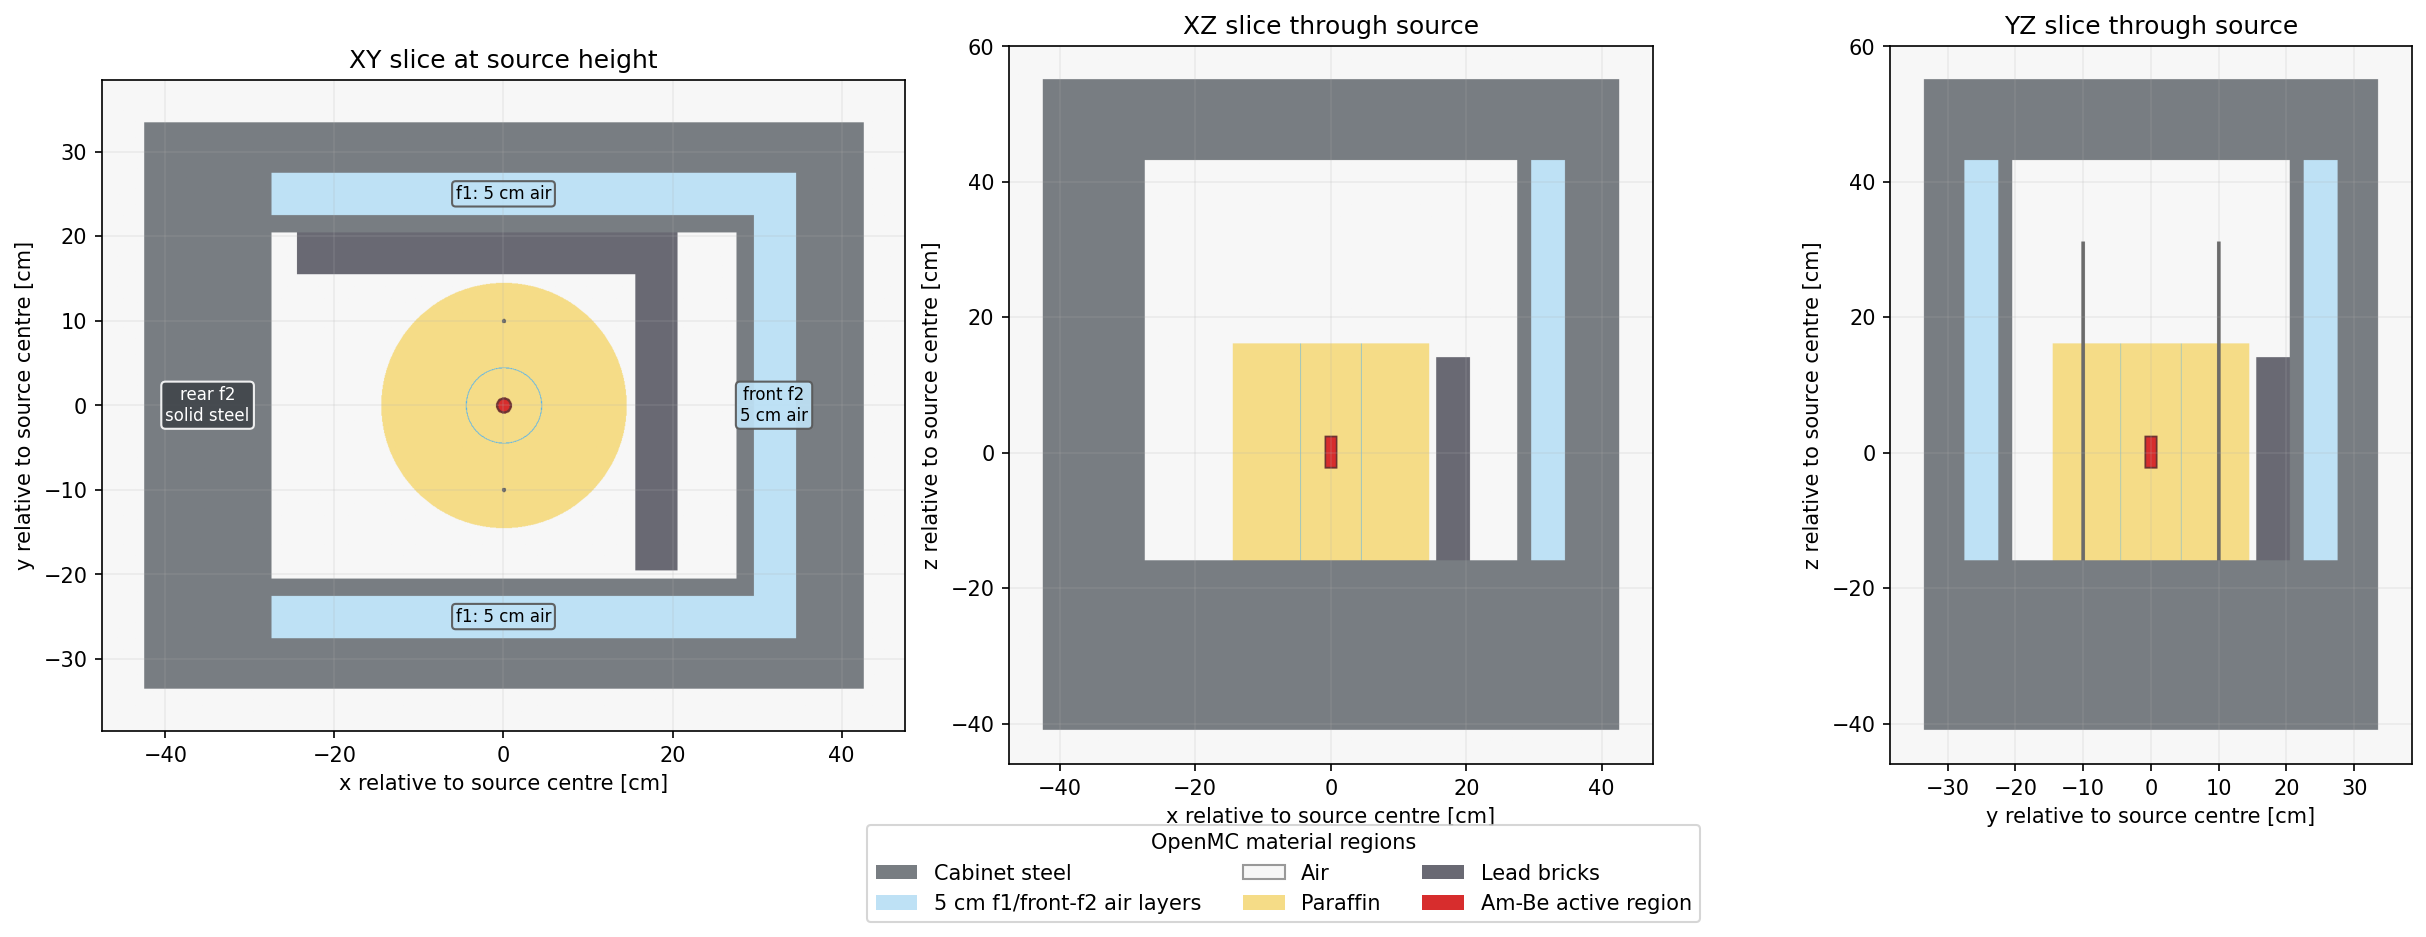

Running ALPHANSO calculation...
Total (alpha, n) yield: 4.268e+06 neutrons/s/g
energy_edges length: 121
spectrum length: 120
ALPHANSO Am-Be spectrum
Spectrum bins: 120
OpenMC energy points: 120
Energy range: 0.05 to 11.95 MeV
Sum of probabilities: 1.0


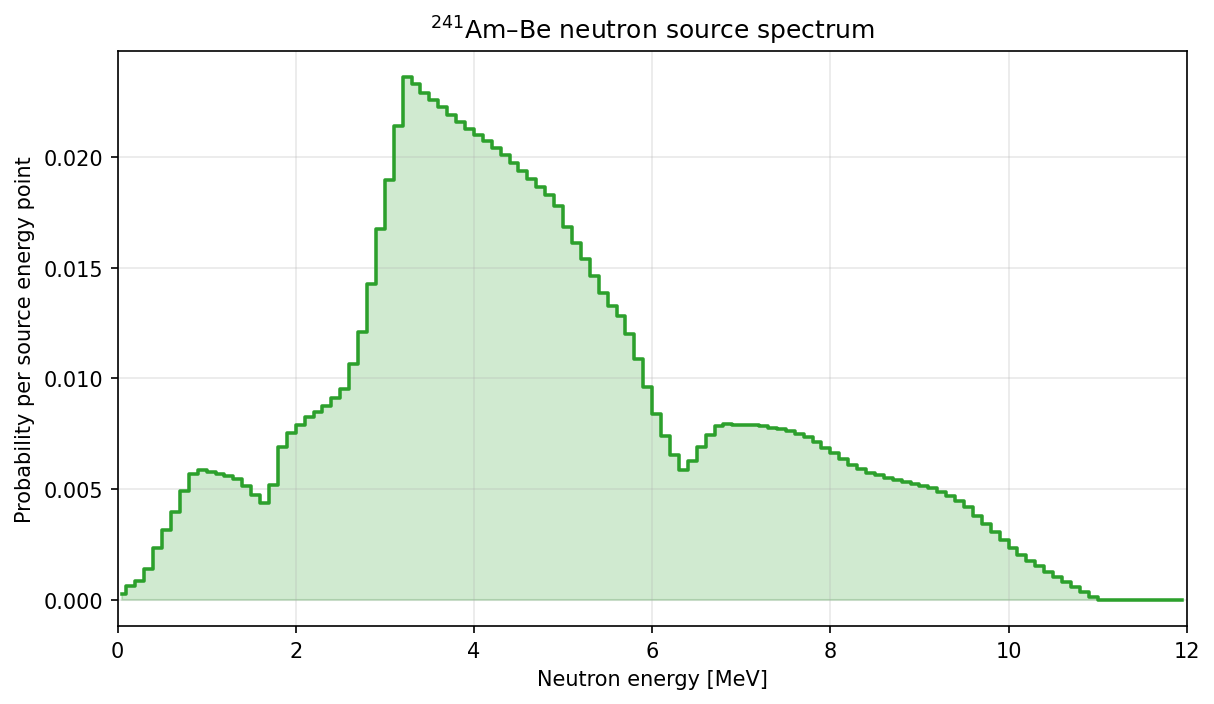

Saved geometry figure: /root/Rfys_VI/RFP-master/Bachelor_projekt/NF_AmBe_Parafifn/H1_f1_sides_and_front_f2_hollow_transport_outputs/geometry/figures/f1_sides_and_front_f2_openmc_slices.png


In [7]:
slice_colors = {}
for cell_name, color in [
    ("cabinet_wall_cell", (120, 125, 130)),
    ("cabinet_void_cell", (190, 225, 245)),
    ("cabinet_air_cell", (247, 247, 247)),
    ("inner_paraffin_cell", (245, 220, 135)),
    ("outer_paraffin_cell", (245, 220, 135)),
    ("plastic_cell", (90, 180, 235)),
    ("source_fill_cell", (215, 45, 45)),
    ("source_shell_cell", (110, 50, 50)),
    ("rod1_cell", (95, 95, 95)),
    ("rod2_cell", (95, 95, 95)),
    ("outside_air_cell", (247, 247, 247)),
]:
    cell_object = base.get(cell_name)
    if cell_object is not None:
        slice_colors[cell_object] = color

for lead_cell in base.get("lead_brick_cells", []):
    slice_colors[lead_cell] = (105, 105, 115)

geometry_figure, geometry_axes = plt.subplots(
    1,
    3,
    figsize=(17.0, 5.5),
    dpi=150,
    layout="constrained",
)

slice_specs = [
    (
        "xy",
        (0.0, 0.0, 0.0),
        (CABINET_X + 10.0, CABINET_Y + 10.0),
        "XY slice at source height",
        "x relative to source centre [cm]",
        "y relative to source centre [cm]",
    ),
    (
        "xz",
        (0.0, 0.0, CABINET_ZCENTER),
        (CABINET_X + 10.0, CABINET_Z + 10.0),
        "XZ slice through source",
        "x relative to source centre [cm]",
        "z relative to source centre [cm]",
    ),
    (
        "yz",
        (0.0, 0.0, CABINET_ZCENTER),
        (CABINET_Y + 10.0, CABINET_Z + 10.0),
        "YZ slice through source",
        "y relative to source centre [cm]",
        "z relative to source centre [cm]",
    ),
]

for axis, specification in zip(geometry_axes, slice_specs):
    basis, origin, width, title, xlabel, ylabel = specification
    root.plot(
        basis=basis,
        origin=origin,
        width=width,
        pixels=(1200, 1200),
        axes=axis,
        color_by="cell",
        colors=slice_colors,
    )
    axis.set_title(title)
    axis.set_xlabel(xlabel)
    axis.set_ylabel(ylabel)
    axis.grid(alpha=0.18)

    if basis == "xy":
        axis.text(
            CABINET_XMIN + 0.5 * CABINET_WALL_X,
            0.0,
            "rear f2\nsolid steel",
            ha="center",
            va="center",
            fontsize=8,
            color="white",
            bbox={
                "boxstyle": "round,pad=0.25",
                "facecolor": (0.25, 0.27, 0.29),
                "edgecolor": "white",
                "alpha": 0.90,
            },
        )
        axis.text(
            0.5 * (
                x_inner_outer_max + x_void_outer_max
            ),
            0.0,
            "front f2\n5 cm air",
            ha="center",
            va="center",
            fontsize=8,
            color="black",
            bbox={
                "boxstyle": "round,pad=0.25",
                "facecolor": (190/255, 225/255, 245/255),
                "edgecolor": "0.35",
                "alpha": 0.94,
            },
        )
        axis.text(
            0.0,
            0.5 * (y_void_outer_min + y_inner_outer_min),
            "f1: 5 cm air",
            ha="center",
            va="center",
            fontsize=8,
            color="black",
            bbox={
                "boxstyle": "round,pad=0.22",
                "facecolor": (190/255, 225/255, 245/255),
                "edgecolor": "0.35",
                "alpha": 0.94,
            },
        )
        axis.text(
            0.0,
            0.5 * (y_inner_outer_max + y_void_outer_max),
            "f1: 5 cm air",
            ha="center",
            va="center",
            fontsize=8,
            color="black",
            bbox={
                "boxstyle": "round,pad=0.22",
                "facecolor": (190/255, 225/255, 245/255),
                "edgecolor": "0.35",
                "alpha": 0.94,
            },
        )

geometry_figure.legend(
    handles=[
        Patch(facecolor=(120/255, 125/255, 130/255), label="Cabinet steel"),
        Patch(facecolor=(190/255, 225/255, 245/255), label="5 cm f1/front-f2 air layers"),
        Patch(facecolor=(247/255, 247/255, 247/255), edgecolor="0.6", label="Air"),
        Patch(facecolor=(245/255, 220/255, 135/255), label="Paraffin"),
        Patch(facecolor=(105/255, 105/255, 115/255), label="Lead bricks"),
        Patch(facecolor=(215/255, 45/255, 45/255), label="Am-Be active region"),
    ],
    loc="lower center",
    bbox_to_anchor=(0.5, -0.12),
    ncol=3,
    title="OpenMC material regions",
)

geometry_png = GEOMETRY_FIGURE_DIR / "f1_sides_and_front_f2_openmc_slices.png"
geometry_pdf = GEOMETRY_FIGURE_DIR / "f1_sides_and_front_f2_openmc_slices.pdf"
geometry_figure.savefig(geometry_png, dpi=300, bbox_inches="tight")
geometry_figure.savefig(geometry_pdf, bbox_inches="tight")
plt.show()
plt.close(geometry_figure)

neutron_energy_dist = ambe_base_model.build_ambe_energy_distribution(
    make_plot=False,
    verbose=True,
)
neutron_energy_mev = np.asarray(neutron_energy_dist.x, dtype=float) / 1.0e6
neutron_probability = np.asarray(neutron_energy_dist.p, dtype=float)

source_figure, source_axis = plt.subplots(figsize=(8.2, 4.8), dpi=150)
source_axis.step(
    neutron_energy_mev,
    neutron_probability,
    where="mid",
    color="tab:green",
    linewidth=1.7,
)
source_axis.fill_between(
    neutron_energy_mev,
    neutron_probability,
    step="mid",
    color="tab:green",
    alpha=0.22,
)
source_axis.set_xlabel("Neutron energy [MeV]")
source_axis.set_ylabel("Probability per source energy point")
source_axis.set_title(r"$^{241}$Am–Be neutron source spectrum")
source_axis.set_xlim(0.0, 12.0)
source_axis.grid(alpha=0.28)
source_figure.tight_layout()
source_figure.savefig(
    GEOMETRY_FIGURE_DIR / "ambe_neutron_source_spectrum.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()
plt.close(source_figure)

print(f"Saved geometry figure: {geometry_png}")


# 4) Measurement-specific neutron transport

The 61 neutron tallies use the established 2 cm numerical scoring cubes.
They estimate the local unperturbed neutron field and do not model the
physical Studsvik detector material. The recorded distance is treated as
the cabinet-to-detector-head gap, with the tally reference point displaced
by the 10.75 cm head radius because the detector was used at 90°.


In [8]:
model_data = ambe_base_model.build_base_neutron_model(
    batches=120,
    particles=50_000,
    inactive=0,
    export_xml=False,
    verbose=True,
    source_evaluation_date=EXPERIMENT_DATE,
)
globals().update(model_data)

SCAN_DET_SIZE = 2.0
STUDSVIK_HEAD_DIAMETER = 21.5
STUDSVIK_HEAD_LENGTH = 23.0
SCAN_DET_OFFSET = STUDSVIK_HEAD_DIAMETER / 2.0
scan_corner_offset = SCAN_DET_OFFSET / np.sqrt(2.0)

P1_MEASUREMENTS = [
    (0, 42), (0, 85), (4, 42), (4, 85), (7, 85),
    (57, 42), (57, 85), (114, 42), (114, 85),
    (176, 42), (176, 85), (199, 42), (199, 85),
    (320, 42), (320, 85), (420, 42), (420, 85),
]
P2_MEASUREMENTS = [
    (0, 85), (2, 55), (5, 85), (30, 85),
    (57, 55), (57, 85), (114, 55), (114, 85),
    (156, 85), (176, 55), (176, 85), (199, 55),
    (199, 85), (300, 85), (321, 55), (321, 85), (420, 55),
]
P3_MEASUREMENTS = [
    (0, 45), (0, 85), (5, 45), (5, 85),
    (57, 45), (57, 85), (100, 85), (114, 45), (114, 85),
    (176, 45), (176, 85), (199, 45), (200, 85),
    (225, 45), (225, 85), (300, 45), (300, 85), (400, 85),
]
P4_MEASUREMENTS = [(0, 42), (20, 42), (71, 42), (85, 45), (152, 113)]
P5_MEASUREMENTS = [(0, 45), (0, 85), (6, 45), (6, 85)]

MEASUREMENTS_BY_POSITION = {
    "P1": P1_MEASUREMENTS,
    "P2": P2_MEASUREMENTS,
    "P3": P3_MEASUREMENTS,
    "P4": P4_MEASUREMENTS,
    "P5": P5_MEASUREMENTS,
}


def z_from_height(height_cm):
    return ambe_base_model.z_from_cabinet_bottom(
        h_cm=height_cm,
        cabinet_zmin=CABINET_ZMIN,
    )


def neutron_point_name(position, distance_cm, height_cm):
    return f"{position}_x{int(distance_cm)}_h{int(height_cm)}"


MEASUREMENT_SCAN_POINTS = {}

for position, measurements in MEASUREMENTS_BY_POSITION.items():
    for distance_cm, height_cm in measurements:
        if position == "P1":
            center = (
                0.0,
                CABINET_YMIN - SCAN_DET_OFFSET - distance_cm,
                z_from_height(height_cm),
            )
        elif position == "P2":
            diagonal = distance_cm / np.sqrt(2.0)
            center = (
                CABINET_XMAX + scan_corner_offset + diagonal,
                CABINET_YMIN - scan_corner_offset - diagonal,
                z_from_height(height_cm),
            )
        elif position == "P3":
            center = (
                CABINET_XMAX + SCAN_DET_OFFSET + distance_cm,
                0.0,
                z_from_height(height_cm),
            )
        elif position == "P4":
            diagonal = distance_cm / np.sqrt(2.0)
            center = (
                CABINET_XMAX + scan_corner_offset + diagonal,
                CABINET_YMAX + scan_corner_offset + diagonal,
                z_from_height(height_cm),
            )
        elif position == "P5":
            center = (
                0.0,
                CABINET_YMAX + SCAN_DET_OFFSET + distance_cm,
                z_from_height(height_cm),
            )
        else:
            raise KeyError(position)

        point_name = neutron_point_name(position, distance_cm, height_cm)
        if point_name in MEASUREMENT_SCAN_POINTS:
            raise KeyError(f"Duplicate neutron scan point: {point_name}")
        MEASUREMENT_SCAN_POINTS[point_name] = {
            "position": position,
            "distance_cm": float(distance_cm),
            "height_cm": float(height_cm),
            "center": tuple(float(value) for value in center),
        }

if len(MEASUREMENT_SCAN_POINTS) != 61:
    raise AssertionError(
        "The neutron scan must contain 61 unique placements; "
        f"found {len(MEASUREMENT_SCAN_POINTS)}."
    )

measurement_scan_total_tallies = [
    ambe_base_model.make_mesh_flux_tally(
        name=f"flux_{point_name}",
        center=data["center"],
        det_size=SCAN_DET_SIZE,
        spectral=False,
    )
    for point_name, data in MEASUREMENT_SCAN_POINTS.items()
]
measurement_scan_all_tallies = openmc.Tallies(
    measurement_scan_total_tallies
)

measurement_scan_settings = ambe_base_model.build_neutron_settings(
    energy_dist=energy_dist,
    batches=NEUTRON_RUN_BATCHES,
    particles=NEUTRON_PARTICLES_PER_BATCH,
    inactive=0,
    source_strength=1.0,
)
measurement_scan_model = openmc.Model(
    geometry=geometry,
    materials=materials,
    settings=measurement_scan_settings,
    tallies=measurement_scan_all_tallies,
)

neutron_point_definition_df = pd.DataFrame([
    {
        "position": data["position"],
        "point_name": point_name,
        "distance_cm": data["distance_cm"],
        "height_cm": data["height_cm"],
        "x_cm": data["center"][0],
        "y_cm": data["center"][1],
        "z_cm": data["center"][2],
        "detector_side_cm": SCAN_DET_SIZE,
        "detector_volume_cm3": SCAN_DET_SIZE**3,
    }
    for point_name, data in MEASUREMENT_SCAN_POINTS.items()
]).sort_values(["position", "height_cm", "distance_cm"])
neutron_point_definition_df.to_csv(
    NEUTRON_TABLE_DIR / "hollow_neutron_scan_point_definition.csv",
    index=False,
)

print(f"Neutron scan points: {len(MEASUREMENT_SCAN_POINTS)}")
print(f"Neutron tallies:     {len(measurement_scan_all_tallies)}")
print(
    "Neutron histories:  "
    f"{NEUTRON_RUN_BATCHES * NEUTRON_PARTICLES_PER_BATCH:.3e}"
)
display(
    neutron_point_definition_df.groupby("position").size().rename("points")
)


Geometry summary:
  Cabinet outer dimensions      = 85.0 x 67.0 x 96.0 cm
  Cabinet x-wall thickness      = 15.0 cm
  Cabinet y-wall thickness      = 13.0 cm
  Hollow cabinet faces          = ('x_max', 'y_min', 'y_max')
  Rear (-x) f2 wall              = 15.0 cm solid steel
  Front (+x) f2 wall stack       = 2.0 cm steel + 5.0 cm air + 8.0 cm steel
  Both f1/y wall stacks          = 2.0 cm steel + 5.0 cm air + 6.0 cm steel
  Cabinet bottom thickness      = 25.0 cm
  Cabinet top thickness         = 12.0 cm
  Cabinet z range               = -41.0 to 55.0 cm
  Cabinet inner x width         = 55.0 cm
  Cabinet inner y width         = 41.0 cm
  Cabinet inner z height        = 59.0 cm
  Cabinet inner z range         = -16.0 to 43.0 cm
  Paraffin radius               = 14.500 cm
  Paraffin height               = 32.000 cm
  Paraffin z range              = -16.000 to 16.000 cm
  Plastic outer radius          = 4.500 cm
  Plastic inner radius          = 4.400 cm
  Source outer radius           

position
P1    17
P2    17
P3    18
P4     5
P5     4
Name: points, dtype: int64

## 4.1) Run or reuse the neutron statepoint

The production calculation uses $200\times100{,}000=2.0\times10^7$
source-neutron histories. Existing results are never silently interpreted
as hollow results: only statepoints inside the dedicated `1H` hollow run
folder are reused.


In [9]:
def normalize_statepoint_path(run_result, run_directory):
    result_path = Path(run_result)
    if not result_path.is_absolute() and not result_path.exists():
        candidate = Path(run_directory) / result_path
        if candidate.exists():
            result_path = candidate
    return result_path.resolve()


existing_neutron_statepoints = sorted(
    NEUTRON_RUN_DIR.glob("statepoint.*.h5"),
    key=lambda path: path.stat().st_mtime_ns,
)

if RUN_NEUTRON_OPENMC:
    print("Running hollow-cabinet neutron transport...")
    measurement_scan_model.export_to_xml(directory=NEUTRON_RUN_DIR)
    neutron_run_result = measurement_scan_model.run(cwd=NEUTRON_RUN_DIR)
    neutron_statepoint_path = normalize_statepoint_path(
        neutron_run_result,
        NEUTRON_RUN_DIR,
    )
elif existing_neutron_statepoints:
    neutron_statepoint_path = existing_neutron_statepoints[-1].resolve()
    print("Reusing existing hollow-cabinet neutron statepoint.")
else:
    neutron_statepoint_path = None
    print(
        "Neutron transport was not run and no hollow statepoint exists. "
        "Set RUN_NEUTRON_OPENMC = True, then rerun from Section 4."
    )

print(f"Neutron statepoint: {neutron_statepoint_path}")


Running hollow-cabinet neutron transport...
                                %%%%%%%%%%%%%%%
                           %%%%%%%%%%%%%%%%%%%%%%%%
                        %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                      %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                    %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                   %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                                    %%%%%%%%%%%%%%%%%%%%%%%%
                                     %%%%%%%%%%%%%%%%%%%%%%%%
                 ###############      %%%%%%%%%%%%%%%%%%%%%%%%
                ##################     %%%%%%%%%%%%%%%%%%%%%%%
                ###################     %%%%%%%%%%%%%%%%%%%%%%%
                ####################     %%%%%%%%%%%%%%%%%%%%%%
                #####################     %%%%%%%%%%%%%%%%%%%%%
                ######################     %%%%%%%%%%%%%%%%%%%%
                #######################     %%%%%%%%%%%%%%%%%%
                 #######################     %%%%%%%%%%%%

## 4.2) Neutron-flux post-processing

OpenMC mesh flux is divided by the 8 cm³ scoring volume and then scaled by
the selected source-specific neutron emission. Exported uncertainties are
OpenMC batch-statistical standard uncertainties only.


In [10]:
def classify_mc_uncertainty(relative_percent):
    if not np.isfinite(relative_percent):
        return "unknown"
    if relative_percent < 5.0:
        return "low"
    if relative_percent < 10.0:
        return "moderate"
    if relative_percent < 25.0:
        return "high"
    return "very high"


if neutron_statepoint_path is None:
    neutron_scan_summary = pd.DataFrame()
    print("Neutron post-processing skipped: no statepoint is available.")
else:
    neutron_rows = []
    detector_volume_cm3 = SCAN_DET_SIZE**3

    with openmc.StatePoint(neutron_statepoint_path) as statepoint:
        available_names = {
            tally.name for tally in statepoint.tallies.values()
        }

        for point_name, point_data in MEASUREMENT_SCAN_POINTS.items():
            tally_name = f"flux_{point_name}"
            if tally_name not in available_names:
                raise LookupError(
                    f"Missing neutron tally '{tally_name}' in "
                    f"{neutron_statepoint_path}."
                )

            tally = statepoint.get_tally(name=tally_name)
            mean_values = np.asarray(tally.mean).ravel()
            std_values = np.asarray(tally.std_dev).ravel()
            if mean_values.size != 1 or std_values.size != 1:
                raise ValueError(f"Neutron tally '{tally_name}' is not scalar.")

            flux_per_source = float(mean_values[0]) / detector_volume_cm3
            u_per_source = float(std_values[0]) / detector_volume_cm3
            flux_physical = flux_per_source * SOURCE_NEUTRON_EMISSION
            u_physical = u_per_source * SOURCE_NEUTRON_EMISSION
            rel_u_percent = (
                100.0 * u_physical / flux_physical
                if flux_physical > 0.0
                else np.nan
            )
            x_cm, y_cm, z_cm = point_data["center"]

            neutron_rows.append({
                "position": point_data["position"],
                "point_name": point_name,
                "distance_cm": point_data["distance_cm"],
                "height_cm": point_data["height_cm"],
                "x_cm": x_cm,
                "y_cm": y_cm,
                "z_cm": z_cm,
                "tally": tally_name,
                "statepoint_file": str(neutron_statepoint_path),
                "detector_volume_cm3": detector_volume_cm3,
                "flux_per_source [n/cm2/source]": flux_per_source,
                "u_mc_per_source [n/cm2/source]": u_per_source,
                "flux_physical [n/cm2/s]": flux_physical,
                "u_mc_physical [n/cm2/s]": u_physical,
                "rel_u_mc [%]": rel_u_percent,
                "mc_uncertainty_class": classify_mc_uncertainty(
                    rel_u_percent
                ),
            })

    neutron_scan_summary = pd.DataFrame(neutron_rows).sort_values(
        ["position", "height_cm", "distance_cm"]
    ).reset_index(drop=True)
    neutron_scan_summary.to_csv(
        NEUTRON_TABLE_DIR / "hollow_neutron_flux_summary_final.csv",
        index=False,
    )

    neutron_metadata_df = pd.DataFrame([
        {"quantity": "geometry", "value": "both f1/y walls and front (+x) f2 hollow; rear (-x) f2 solid"},
        {"quantity": "number_of_scan_points", "value": len(neutron_scan_summary)},
        {"quantity": "source_model", "value": SOURCE_MODEL},
        {"quantity": "source_serial_number", "value": SOURCE_SERIAL_NUMBER},
        {"quantity": "selected_neutron_emission_n_s", "value": SOURCE_NEUTRON_EMISSION},
        {"quantity": "selected_source_date", "value": SOURCE_EVALUATION_DATE},
        {"quantity": "run_batches", "value": NEUTRON_RUN_BATCHES},
        {"quantity": "particles_per_batch", "value": NEUTRON_PARTICLES_PER_BATCH},
        {"quantity": "statepoint_file", "value": str(neutron_statepoint_path)},
        {"quantity": "uncertainty_scope", "value": "OpenMC batch-statistical standard uncertainty only"},
    ])
    neutron_metadata_df.to_csv(
        NEUTRON_METADATA_DIR / "hollow_neutron_transport_metadata.csv",
        index=False,
    )

    display(neutron_scan_summary)


,position,point_name,distance_cm,height_cm,x_cm,y_cm,z_cm,tally,statepoint_file,detector_volume_cm3,flux_per_source [n/cm2/source],u_mc_per_source [n/cm2/source],flux_physical [n/cm2/s],u_mc_physical [n/cm2/s],rel_u_mc [%],mc_uncertainty_class
0,P1,P1_x0_h42,0.0,42.0,0.000000,-44.250000,1.0,flux_P1_x0_h42,/root/Rfys_VI/RFP-master/Bachelor_projekt/NF_A...,8.0,2.003189e-05,4.756707e-07,219.157700,5.204046,2.374567,low
1,P1,P1_x4_h42,4.0,42.0,0.000000,-48.250000,1.0,flux_P1_x4_h42,/root/Rfys_VI/RFP-master/Bachelor_projekt/NF_A...,8.0,1.581801e-05,3.968823e-07,173.055930,4.342066,2.509054,low
2,P1,P1_x57_h42,57.0,42.0,0.000000,-101.250000,1.0,flux_P1_x57_h42,/root/Rfys_VI/RFP-master/Bachelor_projekt/NF_A...,8.0,3.718838e-06,2.207868e-07,40.685718,2.415504,5.936983,moderate
3,P1,P1_x114_h42,114.0,42.0,0.000000,-158.250000,1.0,flux_P1_x114_h42,/root/Rfys_VI/RFP-master/Bachelor_projekt/NF_A...,8.0,1.324226e-06,1.212430e-07,14.487611,1.326452,9.155766,moderate
4,P1,P1_x176_h42,176.0,42.0,0.000000,-220.250000,1.0,flux_P1_x176_h42,/root/Rfys_VI/RFP-master/Bachelor_projekt/NF_A...,8.0,6.716858e-07,8.638170e-08,7.348538,0.945054,12.860433,high
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
56,P4,P4_x152_h113,152.0,113.0,157.581629,148.581629,72.0,flux_P4_x152_h113,/root/Rfys_VI/RFP-master/Bachelor_projekt/NF_A...,8.0,3.453944e-07,6.301100e-08,3.778767,0.689368,18.243200,high
57,P5,P5_x0_h45,0.0,45.0,0.000000,44.250000,4.0,flux_P5_x0_h45,/root/Rfys_VI/RFP-master/Bachelor_projekt/NF_A...,8.0,1.547740e-05,4.185780e-07,169.329598,4.579427,2.704446,low
58,P5,P5_x6_h45,6.0,45.0,0.000000,50.250000,4.0,flux_P5_x6_h45,/root/Rfys_VI/RFP-master/Bachelor_projekt/NF_A...,8.0,1.244728e-05,3.868513e-07,136.178703,4.232324,3.107919,low
59,P5,P5_x0_h85,0.0,85.0,0.000000,44.250000,44.0,flux_P5_x0_h85,/root/Rfys_VI/RFP-master/Bachelor_projekt/NF_A...,8.0,6.734712e-06,2.815454e-07,73.680708,3.080230,4.180511,low


# 5) ALPHANSO gamma-line source and physical scaling

The shared gamma-line builder must already exist in
`ambe_base_model.py`. This notebook does not inject code into that module.

ALPHANSO supplies both the discrete gamma-line distribution and model yields.
The line probabilities are normalized to one source photon for OpenMC. The
absolute photon rate is calculated separately from the ratio of the total
ALPHANSO gamma and neutron yields:

$$
\frac{S_\gamma}{S_n}=\frac{Y_\gamma}{Y_n}.
$$

This ratio is an ALPHANSO model result based on the adopted Am–Be mixture
approximation. It is not a source-specific photon-yield measurement from the
AMN 5000/1365 factory certificate.


In [11]:
# Gamma-specific output aliases used by the reviewed gamma workflow.
OUTPUT_DIR = GAMMA_OUTPUT_DIR
TABLE_DIR = GAMMA_TABLE_DIR
FIGURE_DIR = GAMMA_FIGURE_DIR
METADATA_DIR = GAMMA_METADATA_DIR

# Rebuild once through the fixed adapter so the source record and all
# gamma group geometries use the same hollow cabinet configuration.
gamma_base = ambe_base_model.build_base_model(
    export_xml=False,
    verbose=True,
    source_evaluation_date=EXPERIMENT_DATE,
)
globals().update(gamma_base)

if gamma_base["CABINET_CONFIG"] != HOLLOW_CONFIG:
    raise AssertionError("Gamma setup did not retain HOLLOW_CONFIG.")


Geometry summary:
  Cabinet outer dimensions      = 85.0 x 67.0 x 96.0 cm
  Cabinet x-wall thickness      = 15.0 cm
  Cabinet y-wall thickness      = 13.0 cm
  Hollow cabinet faces          = ('x_max', 'y_min', 'y_max')
  Rear (-x) f2 wall              = 15.0 cm solid steel
  Front (+x) f2 wall stack       = 2.0 cm steel + 5.0 cm air + 8.0 cm steel
  Both f1/y wall stacks          = 2.0 cm steel + 5.0 cm air + 6.0 cm steel
  Cabinet bottom thickness      = 25.0 cm
  Cabinet top thickness         = 12.0 cm
  Cabinet z range               = -41.0 to 55.0 cm
  Cabinet inner x width         = 55.0 cm
  Cabinet inner y width         = 41.0 cm
  Cabinet inner z height        = 59.0 cm
  Cabinet inner z range         = -16.0 to 43.0 cm
  Paraffin radius               = 14.500 cm
  Paraffin height               = 32.000 cm
  Paraffin z range              = -16.000 to 16.000 cm
  Plastic outer radius          = 4.500 cm
  Plastic inner radius          = 4.400 cm
  Source outer radius           

Am-Be gamma emission lines:
  Total gamma yield: 2.783366e+06
  E = 3.2138 MeV, yield = 1.559798e+02, probability = 0.005604 %
  E = 4.4389 MeV, yield = 2.783210e+06, probability = 99.994396 %

Dominant gamma line:
  E = 4.4389 MeV
  probability = 99.994396 %


,E_gamma [MeV],line_yield,relative_probability,relative_probability [%]
0,3.2138,1.559798e+02,0.000056,0.005604
1,4.4389,2.783210e+06,0.999944,99.994396



Gamma source scaling:
  ALPHANSO neutron yield (an_yield): 4.268302e+06
  ALPHANSO gamma yield:              2.783366e+06
  ALPHANSO gamma/neutron ratio:      0.652101 photons/neutron
  Physical neutron source:           1.094044e+07 n/s
  Estimated physical gamma source:   7.134276e+06 photons/s


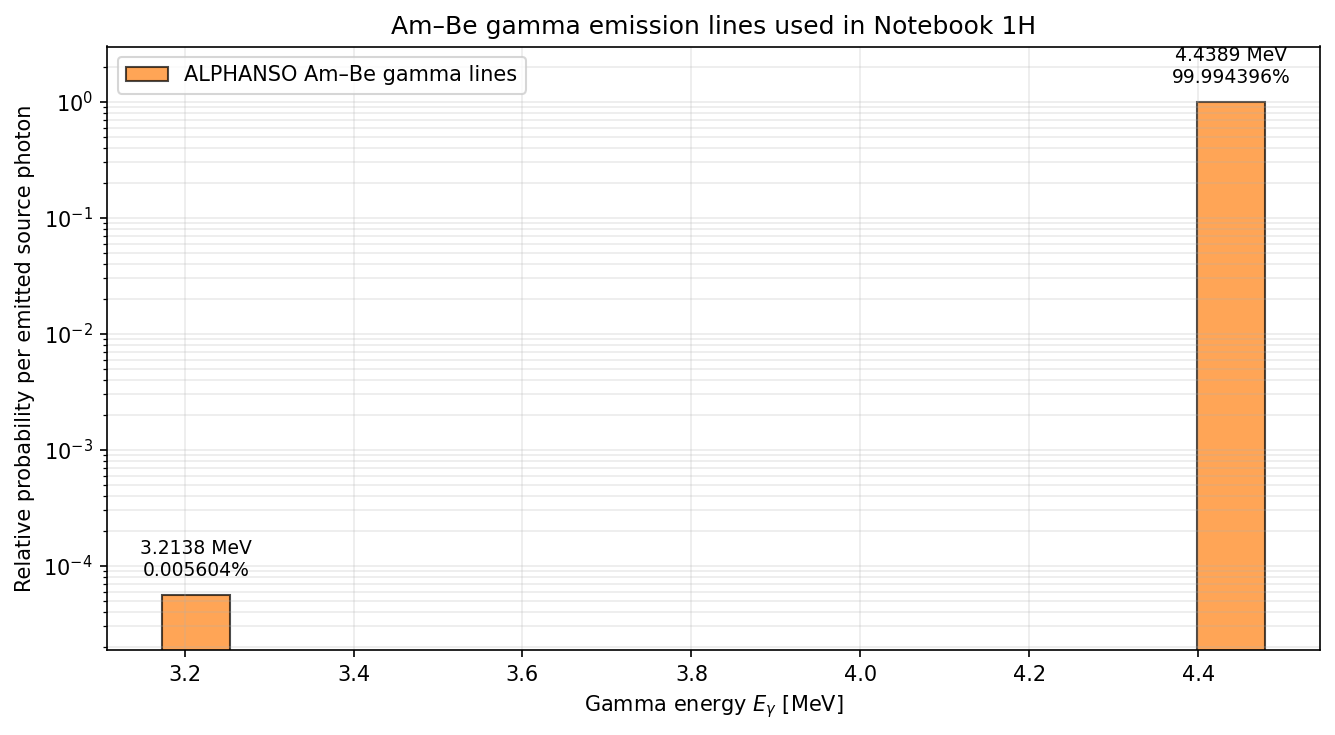

Saved gamma-line table:  /root/Rfys_VI/RFP-master/Bachelor_projekt/NF_AmBe_Parafifn/H1_f1_sides_and_front_f2_hollow_transport_outputs/gamma/tables/ambe_gamma_lines_used_in_1h_hollow.csv
Saved gamma-line figure: /root/Rfys_VI/RFP-master/Bachelor_projekt/NF_AmBe_Parafifn/H1_f1_sides_and_front_f2_hollow_transport_outputs/gamma/figures/section_2_ambe_gamma_emission_lines.png


In [12]:
if not hasattr(ambe_base_model, "build_ambe_gamma_line_distribution"):
    raise AttributeError(
        "ambe_base_model.py does not contain "
        "build_ambe_gamma_line_distribution(). Update the shared module "
        "before running Notebook 1H."
    )


gamma_energy_dist, gamma_data = (
    ambe_base_model.build_ambe_gamma_line_distribution(
        make_plot=False,
        verbose=True,
    )
)

gamma_energies_mev = np.asarray(
    gamma_data["gamma_energies_mev"],
    dtype=float,
)
gamma_line_yields = np.asarray(
    gamma_data["gamma_line_yields"],
    dtype=float,
)
gamma_prob = np.asarray(
    gamma_data["gamma_prob"],
    dtype=float,
)

if not (
    gamma_energies_mev.ndim == 1
    and gamma_line_yields.shape == gamma_energies_mev.shape
    and gamma_prob.shape == gamma_energies_mev.shape
    and gamma_energies_mev.size > 0
):
    raise ValueError("The ALPHANSO gamma-line arrays are inconsistent.")

if not np.all(np.isfinite(gamma_energies_mev)):
    raise ValueError("Gamma-line energies contain non-finite values.")

if not np.all(np.isfinite(gamma_line_yields)):
    raise ValueError("Gamma-line yields contain non-finite values.")

if not np.all(np.isfinite(gamma_prob)) or np.any(gamma_prob < 0.0):
    raise ValueError("Gamma-line probabilities are invalid.")

if not np.isclose(gamma_prob.sum(), 1.0, rtol=1.0e-10, atol=1.0e-12):
    raise ValueError(
        "Gamma-line probabilities are not normalized to one. "
        f"Found sum = {gamma_prob.sum():.12g}."
    )


alphanso_results = gamma_data.get("alphanso_results")

if not isinstance(alphanso_results, dict):
    raise RuntimeError(
        "ALPHANSO results are unavailable. A fallback line spectrum is "
        "not sufficient for the final physical gamma normalization."
    )

if "an_yield" in alphanso_results:
    alphanso_neutron_yield = float(alphanso_results["an_yield"])
    alphanso_neutron_yield_key = "an_yield"
elif "combined_yield" in alphanso_results:
    alphanso_neutron_yield = float(alphanso_results["combined_yield"])
    alphanso_neutron_yield_key = "combined_yield"
else:
    raise KeyError(
        "ALPHANSO results contain neither 'an_yield' nor "
        "'combined_yield'."
    )

alphanso_gamma_yield = float(gamma_data["gamma_yield"])

for name, value in [
    ("ALPHANSO neutron yield", alphanso_neutron_yield),
    ("ALPHANSO gamma yield", alphanso_gamma_yield),
]:
    if not np.isfinite(value) or value <= 0.0:
        raise ValueError(f"{name} must be finite and positive; got {value}.")


GAMMA_TO_NEUTRON_RATIO_ALPHANSO = (
    alphanso_gamma_yield / alphanso_neutron_yield
)

GAMMA_SOURCE_EMISSION = (
    GAMMA_TO_NEUTRON_RATIO_ALPHANSO
    * SOURCE_NEUTRON_EMISSION
)

# Alias retained for compatibility with shared-model metadata conventions.
SOURCE_GAMMA_EMISSION = GAMMA_SOURCE_EMISSION

GAMMA_SOURCE_NORMALIZATION_STATUS = (
    "decay-corrected source-specific neutron emission multiplied by the "
    "ALPHANSO total gamma-to-neutron yield ratio"
)


gamma_lines_df = pd.DataFrame({
    "E_gamma [MeV]": gamma_energies_mev,
    "line_yield": gamma_line_yields,
    "relative_probability": gamma_prob,
    "relative_probability [%]": 100.0 * gamma_prob,
})

gamma_lines_csv = TABLE_DIR / "ambe_gamma_lines_used_in_1h_hollow.csv"
gamma_lines_df.to_csv(gamma_lines_csv, index=False)

display(gamma_lines_df)

print()
print("Gamma source scaling:")
print(
    f"  ALPHANSO neutron yield ({alphanso_neutron_yield_key}): "
    f"{alphanso_neutron_yield:.6e}"
)
print(f"  ALPHANSO gamma yield:              {alphanso_gamma_yield:.6e}")
print(
    "  ALPHANSO gamma/neutron ratio:      "
    f"{GAMMA_TO_NEUTRON_RATIO_ALPHANSO:.6f} photons/neutron"
)
print(f"  Physical neutron source:           {SOURCE_NEUTRON_EMISSION:.6e} n/s")
print(f"  Estimated physical gamma source:   {GAMMA_SOURCE_EMISSION:.6e} photons/s")


# ------------------------------------------------------------
# Save the source-line figure
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(9, 5), dpi=150)

ax.bar(
    gamma_energies_mev,
    gamma_prob,
    width=0.08,
    align="center",
    alpha=0.70,
    color="tab:orange",
    edgecolor="black",
    label="ALPHANSO Am–Be gamma lines",
)

for energy, probability in zip(gamma_energies_mev, gamma_prob):
    ax.text(
        energy,
        probability * 1.35,
        f"{energy:.4f} MeV\n{100.0 * probability:.6f}%",
        ha="center",
        va="bottom",
        fontsize=9,
    )

positive_probabilities = gamma_prob[gamma_prob > 0.0]
ax.set_ylim(
    positive_probabilities.min() / 3.0,
    positive_probabilities.max() * 3.0,
)
ax.set_yscale("log")
ax.set_xlabel(r"Gamma energy $E_\gamma$ [MeV]")
ax.set_ylabel("Relative probability per emitted source photon")
ax.set_title("Am–Be gamma emission lines used in Notebook 1H")
ax.grid(True, which="both", alpha=0.25)
ax.legend()

fig.tight_layout()

gamma_lines_figure_path = (
    FIGURE_DIR / "section_2_ambe_gamma_emission_lines.png"
)
fig.savefig(gamma_lines_figure_path, dpi=300, bbox_inches="tight")
plt.show()
plt.close(fig)

print(f"Saved gamma-line table:  {gamma_lines_csv}")
print(f"Saved gamma-line figure: {gamma_lines_figure_path}")


# ------------------------------------------------------------
# Photon-source and fixed-source settings helpers
# ------------------------------------------------------------

def build_gamma_source(gamma_energy_distribution, source_strength=1.0):
    """Build an isotropic point photon source at the capsule centre."""

    source = openmc.IndependentSource(
        space=openmc.stats.Point((0.0, 0.0, 0.0)),
        angle=openmc.stats.Isotropic(),
        energy=gamma_energy_distribution,
        particle="photon",
    )
    source.strength = float(source_strength)
    return source


def build_gamma_settings(
    gamma_energy_distribution,
    batches,
    particles,
    inactive=0,
    source_strength=1.0,
    seed=20260315,
):
    """Build fixed-source OpenMC settings for photon transport."""

    settings = openmc.Settings()
    settings.run_mode = "fixed source"
    settings.source = build_gamma_source(
        gamma_energy_distribution=gamma_energy_distribution,
        source_strength=source_strength,
    )
    settings.batches = int(batches)
    settings.particles = int(particles)
    settings.inactive = int(inactive)
    settings.seed = int(seed)
    settings.photon_transport = True

    return settings


## 5.1) Measurement-specific P1–P5 gamma scan points and LND 712 geometry

The GCA-07W-DL operation manual states that the instrument uses an external
wand containing a neon-plus-halogen Geiger–Mueller tube. The manual specifies
a mica end window with an effective diameter of $0.38''$ and an areal density
of $1.5$–$2.0\ \mathrm{mg\,cm^{-2}}$ (pp. 3–4 and 31). The current Images SI
product page identifies the tube in the GCA-07W-DL as an LND 712.

The LND 712 manufacturer specification gives the dimensions of the effective
region as

$$
d_\mathrm{eff}=9.1\ \mathrm{mm}=0.91\ \mathrm{cm},
\qquad
L_\mathrm{eff}=38.1\ \mathrm{mm}=3.81\ \mathrm{cm}.
$$

The sensitive region is therefore approximated by a right circular cylinder:

$$
V_\mathrm{LND712}
=
\pi\left(\frac{d_\mathrm{eff}}{2}\right)^2L_\mathrm{eff}
=
2.478\ \mathrm{cm^3}.
$$

The GCA manual's $0.38''$ window value is a rounded instrument-level value;
the tube-manufacturer value $0.36''=9.1\ \mathrm{mm}$ is used for the active
cylinder.

Sources:

- [Images SI, GCA-07W-DL Operation Manual](https://www.imagesco.com/geiger/pdf/GCA-07W-DL.pdf), pp. 3–4 and 31;
- [Images SI, GCA-07W-DL product page](https://www.imagesco.com/geiger/digital-geiger-counter-dl.html);
- [LND, Model 712 manufacturer specification](https://www.lndinc.com/products/geiger-mueller-tubes/712/).

The code below uses the following explicit experimental convention:

1. `distance_cm` is interpreted as the gap from the cabinet surface to the
   mica-window plane;
2. the mica window faces the cabinet, so the active-cylinder axis is radial and
   points away from the cabinet;
3. the active-volume reference point is the cylinder centre, located
   $L_\mathrm{eff}/2=1.905\ \mathrm{cm}$ behind the mica window.

If the recorded distance was measured to the outer wand housing rather than to
the mica window, `MEASUREMENT_REFERENCE_TO_MICA_CM` must be replaced by the
measured housing-to-window distance. If the wand was side-on or vertical during
the experiment, the axis vectors must likewise be changed to match the actual
setup. The manual does not determine either of those experimental details.

Heights are measured from the cabinet bottom and converted to OpenMC
$z$ coordinates with the shared geometry helper.


In [13]:
def z_from_height(height_cm):
    """Convert height above the cabinet bottom to OpenMC z-coordinate."""

    return ambe_base_model.z_from_cabinet_bottom(
        h_cm=height_cm,
        cabinet_zmin=CABINET_ZMIN,
    )


def normalized_vector(vector):
    """Return a finite, three-component unit vector."""

    vector = np.asarray(vector, dtype=float)

    if vector.shape != (3,) or not np.all(np.isfinite(vector)):
        raise ValueError(f"Invalid direction vector: {vector}")

    norm = np.linalg.norm(vector)

    if norm <= 0.0:
        raise ValueError("A detector-axis vector cannot have zero length.")

    return vector / norm


def make_gamma_point_name(position, distance_cm, height_cm):
    return f"{position}_x{int(distance_cm)}_h{int(height_cm)}"


def add_gamma_scan_point(
    scan_dictionary,
    position,
    distance_cm,
    height_cm,
    cabinet_surface_point,
    outward_unit_vector,
):
    """Add one detector-specific LND 712 active-volume reference point."""

    point_name = make_gamma_point_name(
        position,
        distance_cm,
        height_cm,
    )

    if point_name in scan_dictionary:
        raise KeyError(f"Duplicate gamma scan point: {point_name}")

    surface_point = np.asarray(cabinet_surface_point, dtype=float)
    outward = normalized_vector(outward_unit_vector)

    mica_window_center = (
        surface_point
        + (
            float(distance_cm)
            + MEASUREMENT_REFERENCE_TO_MICA_CM
        ) * outward
    )

    active_center = (
        mica_window_center
        + 0.5 * LND712_EFFECTIVE_LENGTH_CM * outward
    )

    scan_dictionary[point_name] = {
        "position": position,
        "distance_cm": float(distance_cm),
        "height_cm": float(height_cm),
        "center": tuple(float(value) for value in active_center),
        "mica_window_center": tuple(
            float(value) for value in mica_window_center
        ),
        "axis_unit_vector": tuple(float(value) for value in outward),
    }


# ------------------------------------------------------------
# Documented GCA-07W-DL / LND 712 dimensions
# ------------------------------------------------------------

GCA_MANUAL_WINDOW_DIAMETER_CM = 0.38 * 2.54
GCA_MANUAL_WINDOW_AREAL_DENSITY_MG_CM2 = (1.5, 2.0)

LND712_EFFECTIVE_DIAMETER_CM = 0.91
LND712_EFFECTIVE_RADIUS_CM = LND712_EFFECTIVE_DIAMETER_CM / 2.0
LND712_EFFECTIVE_LENGTH_CM = 3.81
LND712_MAXIMUM_DIAMETER_CM = 1.51
LND712_MAXIMUM_LENGTH_CM = 4.92

LND712_ACTIVE_VOLUME_CM3 = (
    np.pi
    * LND712_EFFECTIVE_RADIUS_CM**2
    * LND712_EFFECTIVE_LENGTH_CM
)

# Experimental distance convention used in this notebook.
# A nonzero value is required only if the recorded reference surface was
# separated from the mica-window plane. It must then be measured physically.
MEASUREMENT_REFERENCE_TO_MICA_CM = 0.0

GAMMA_REFERENCE_OFFSET_CM = (
    MEASUREMENT_REFERENCE_TO_MICA_CM
    + 0.5 * LND712_EFFECTIVE_LENGTH_CM
)

GAMMA_DETECTOR_ORIENTATION = (
    "end-on: mica window faces the cabinet; active axis is radial"
)

GAMMA_DISTANCE_REFERENCE = (
    "distance_cm is the cabinet-surface-to-mica-window gap"
)


P1_MEASUREMENTS = [
    (0, 42), (0, 85),
    (4, 42), (4, 85),
    (7, 85),
    (57, 42), (57, 85),
    (114, 42), (114, 85),
    (176, 42), (176, 85),
    (199, 42), (199, 85),
    (320, 42), (320, 85),
    (420, 42), (420, 85),
]

P2_MEASUREMENTS = [
    (0, 85),
    (2, 55),
    (5, 85),
    (30, 85),
    (57, 55), (57, 85),
    (114, 55), (114, 85),
    (156, 85),
    (176, 55), (176, 85),
    (199, 55), (199, 85),
    (300, 85),
    (321, 55), (321, 85),
    (420, 55),
]

P3_MEASUREMENTS = [
    (0, 45), (0, 85),
    (5, 45), (5, 85),
    (57, 45), (57, 85),
    (100, 85),
    (114, 45), (114, 85),
    (176, 45), (176, 85),
    (199, 45),
    (200, 85),
    (225, 45), (225, 85),
    (300, 45), (300, 85),
    (400, 85),
]

P4_MEASUREMENTS = [
    (0, 42),
    (20, 42),
    (71, 42),
    (85, 45),
    (152, 113),
]

P5_MEASUREMENTS = [
    (0, 45),
    (0, 85),
    (6, 45),
    (6, 85),
]


MEASUREMENTS_BY_POSITION = {
    "P1": P1_MEASUREMENTS,
    "P2": P2_MEASUREMENTS,
    "P3": P3_MEASUREMENTS,
    "P4": P4_MEASUREMENTS,
    "P5": P5_MEASUREMENTS,
}

CABINET_SURFACE_XY_BY_POSITION = {
    "P1": (0.0, CABINET_YMIN),
    "P2": (CABINET_XMAX, CABINET_YMIN),
    "P3": (CABINET_XMAX, 0.0),
    "P4": (CABINET_XMAX, CABINET_YMAX),
    "P5": (0.0, CABINET_YMAX),
}

OUTWARD_UNIT_VECTOR_BY_POSITION = {
    "P1": normalized_vector((0.0, -1.0, 0.0)),
    "P2": normalized_vector((1.0, -1.0, 0.0)),
    "P3": normalized_vector((1.0, 0.0, 0.0)),
    "P4": normalized_vector((1.0, 1.0, 0.0)),
    "P5": normalized_vector((0.0, 1.0, 0.0)),
}


GAMMA_SCAN_POINTS = {}

for position, measurements in MEASUREMENTS_BY_POSITION.items():
    surface_x_cm, surface_y_cm = CABINET_SURFACE_XY_BY_POSITION[position]
    outward = OUTWARD_UNIT_VECTOR_BY_POSITION[position]

    for distance_cm, height_cm in measurements:
        cabinet_surface_point = (
            surface_x_cm,
            surface_y_cm,
            z_from_height(height_cm),
        )

        add_gamma_scan_point(
            scan_dictionary=GAMMA_SCAN_POINTS,
            position=position,
            distance_cm=distance_cm,
            height_cm=height_cm,
            cabinet_surface_point=cabinet_surface_point,
            outward_unit_vector=outward,
        )


if len(GAMMA_SCAN_POINTS) != 61:
    raise ValueError(
        "The measurement-specific gamma scan must contain 61 points; "
        f"found {len(GAMMA_SCAN_POINTS)}."
    )


gamma_point_definition_df = pd.DataFrame([
    {
        "position": data["position"],
        "point_name": point_name,
        "distance_cm": data["distance_cm"],
        "height_cm": data["height_cm"],
        "x_cm": data["center"][0],
        "y_cm": data["center"][1],
        "z_cm": data["center"][2],
        "mica_x_cm": data["mica_window_center"][0],
        "mica_y_cm": data["mica_window_center"][1],
        "mica_z_cm": data["mica_window_center"][2],
        "axis_x": data["axis_unit_vector"][0],
        "axis_y": data["axis_unit_vector"][1],
        "axis_z": data["axis_unit_vector"][2],
        "detector_volume_cm3": LND712_ACTIVE_VOLUME_CM3,
    }
    for point_name, data in GAMMA_SCAN_POINTS.items()
])

gamma_point_count_df = (
    gamma_point_definition_df
    .groupby("position")
    .size()
    .rename("number_of_points")
    .reset_index()
)

print("Measurement-specific LND 712 gamma scan points created.")
print(f"Total gamma scan points:       {len(GAMMA_SCAN_POINTS)}")
print(f"Effective detector diameter:   {LND712_EFFECTIVE_DIAMETER_CM:.3f} cm")
print(f"Effective detector length:     {LND712_EFFECTIVE_LENGTH_CM:.3f} cm")
print(f"Active tally volume:           {LND712_ACTIVE_VOLUME_CM3:.6f} cm3")
print(f"Centre offset from reference:  {GAMMA_REFERENCE_OFFSET_CM:.3f} cm")
print(f"Orientation assumption:        {GAMMA_DETECTOR_ORIENTATION}")
display(gamma_point_count_df)


Measurement-specific LND 712 gamma scan points created.
Total gamma scan points:       61
Effective detector diameter:   0.910 cm
Effective detector length:     3.810 cm
Active tally volume:           2.477979 cm3
Centre offset from reference:  1.905 cm
Orientation assumption:        end-on: mica window faces the cabinet; active axis is radial


,position,number_of_points
0,P1,17
1,P2,17
2,P3,18
3,P4,5
4,P5,4


## 5.2) LND 712-shaped photon-flux tallies and variance-reduced production settings

Each scan point is represented by a finite right circular cylinder with the
LND 712 effective radius $0.455\ \mathrm{cm}$ and effective length
$3.81\ \mathrm{cm}$. The cylinder axis follows the detector-axis vector
defined in Section 3.

OpenMC 0.15.x cannot rotate a structured `MeshFilter`. Each detector volume is
therefore constructed directly with CSG surfaces:

- an `openmc.Quadric` describes the infinite cylindrical side surface;
- two `openmc.Plane` surfaces close the active length;
- an air-filled `openmc.Cell` contains the finite active volume;
- an `openmc.CellFilter` scores the photon `flux` in that cell.

The cell has the same air fill as the surrounding outside-air cell, so the
added boundaries do not introduce detector material or perturb photon
interactions. The result remains an incident-flux average, not a full GM-tube
response model.

The placements `P1_x4_h85` and `P1_x7_h85` lie only $3\ \mathrm{cm}$ apart
along the same axis, while each active cylinder is $3.81\ \mathrm{cm}$ long.
They cannot coexist as ordinary CSG cells in one geometry. Conservative
overlap detection therefore divides the 61 placements into group 1 with 60
cells and group 2 with the remaining P1 cell. Every reported point retains the
complete $2.478\ \mathrm{cm^3}$ active volume.

## Group 1: MAGIC weight windows and an uncertainty trigger

Group 1 is evaluated in two statistically separate stages:

1. A dedicated generation run uses `openmc.WeightWindowGenerator` with
   `method="magic"` and `particle_type="photon"`. A coarse regular mesh covers
   the source, cabinet and every group-1 detector centre. The resulting
   `weight_windows.h5` file contains the spatial importance map.
2. A separate production run loads that file. A `rel_err` trigger with
   `threshold=0.10` and `ignore_zeros=False` is attached to every group-1
   scalar flux tally. OpenMC treats the configured 200 batches as a minimum,
   checks convergence every 20 batches and may continue to at most 800
   batches. The notebook audits the final statepoint and stops before plotting
   if any group-1 tally remains above 10%. (It's sæt to 80% right now)

The generation and production runs use different random-number seeds. The
weight-window generation histories are therefore not counted as production
histories. Weight windows change particle sampling and statistical weights,
not the expected tally mean.

The OpenMC documentation warns that weight-window splitting can make each
source history much more expensive. Both group-1 stages therefore use 25,000
source photons per batch rather than the former 200,000. The production run
stops according to uncertainty, not a preselected total history count.

## Group 2: separate hollow analog run

Group 2 uses a separate 800-batch, 200,000-photon-per-batch analog run.
The first hollow execution must generate its dedicated statepoint; a
statepoint from the solid geometry is not reusable. Later executions may
reuse the statepoint from the dedicated Notebook 1H hollow run folder.

OpenMC references:

- [Variance reduction and weight-window workflow](https://docs.openmc.org/en/stable/usersguide/variance_reduction.html);
- [WeightWindowGenerator](https://docs.openmc.org/en/stable/pythonapi/generated/openmc.WeightWindowGenerator.html);
- [Trigger](https://docs.openmc.org/en/stable/pythonapi/generated/openmc.Trigger.html);
- [Settings](https://docs.openmc.org/en/stable/pythonapi/generated/openmc.Settings.html);
- [CellFilter](https://docs.openmc.org/en/stable/pythonapi/generated/openmc.CellFilter.html).


In [17]:
def parse_openmc_version(version_text):
    """Return the numeric major, minor and patch components."""

    match = re.match(r"^(\d+)\.(\d+)\.(\d+)", str(version_text))

    if match is None:
        return None

    return tuple(int(value) for value in match.groups())


def make_finite_cylinder_region(
    name,
    center,
    axis_unit_vector,
    radius_cm,
    length_cm,
):
    """Return an arbitrarily oriented finite-cylinder CSG region."""

    center = np.asarray(center, dtype=float)
    axis = normalized_vector(axis_unit_vector)
    radius_cm = float(radius_cm)
    length_cm = float(length_cm)

    if center.shape != (3,) or not np.all(np.isfinite(center)):
        raise ValueError(f"Invalid cylinder center for {name}: {center}")

    if radius_cm <= 0.0 or length_cm <= 0.0:
        raise ValueError(
            f"Cylinder dimensions must be positive for {name}."
        )

    # For p = r - center, the infinite cylinder is
    # p.T @ (I - axis axis.T) @ p = radius**2.
    transverse_projection = np.eye(3) - np.outer(axis, axis)
    linear = -2.0 * transverse_projection @ center
    constant = (
        center @ transverse_projection @ center
        - radius_cm**2
    )

    side = openmc.Quadric(
        a=transverse_projection[0, 0],
        b=transverse_projection[1, 1],
        c=transverse_projection[2, 2],
        d=2.0 * transverse_projection[0, 1],
        e=2.0 * transverse_projection[1, 2],
        f=2.0 * transverse_projection[0, 2],
        g=linear[0],
        h=linear[1],
        j=linear[2],
        k=constant,
        name=f"{name} cylindrical side",
    )

    center_projection = float(axis @ center)
    half_length = 0.5 * length_cm

    lower_cap = openmc.Plane(
        a=axis[0],
        b=axis[1],
        c=axis[2],
        d=center_projection - half_length,
        name=f"{name} lower cap",
    )

    upper_cap = openmc.Plane(
        a=axis[0],
        b=axis[1],
        c=axis[2],
        d=center_projection + half_length,
        name=f"{name} upper cap",
    )

    return -side & +lower_cap & -upper_cap


def detector_bounding_sphere_radius(radius_cm, length_cm):
    """Return the radius of a sphere enclosing a finite cylinder."""

    return float(np.hypot(radius_cm, 0.5 * length_cm))


def detector_volumes_may_overlap(first_point, second_point):
    """Conservatively detect overlap using enclosing spheres."""

    first_center = np.asarray(first_point["center"], dtype=float)
    second_center = np.asarray(second_point["center"], dtype=float)
    center_distance = float(np.linalg.norm(first_center - second_center))

    enclosing_radius = detector_bounding_sphere_radius(
        LND712_EFFECTIVE_RADIUS_CM,
        LND712_EFFECTIVE_LENGTH_CM,
    )

    return center_distance < 2.0 * enclosing_radius - 1.0e-10


def make_nonoverlapping_transport_groups(scan_points):
    """Greedily colour the conservative detector-overlap graph."""

    groups = []
    overlap_pairs = []
    point_names = list(scan_points)

    for first_index, first_name in enumerate(point_names):
        for second_name in point_names[first_index + 1:]:
            if detector_volumes_may_overlap(
                scan_points[first_name],
                scan_points[second_name],
            ):
                overlap_pairs.append((first_name, second_name))

    for point_name in point_names:
        for group in groups:
            if all(
                not detector_volumes_may_overlap(
                    scan_points[point_name],
                    scan_points[other_name],
                )
                for other_name in group
            ):
                group.append(point_name)
                break
        else:
            groups.append([point_name])

    assigned_names = [
        point_name
        for group in groups
        for point_name in group
    ]

    if sorted(assigned_names) != sorted(point_names):
        raise RuntimeError(
            "The transport grouping did not assign every scan point once."
        )

    for group in groups:
        for first_index, first_name in enumerate(group):
            for second_name in group[first_index + 1:]:
                if detector_volumes_may_overlap(
                    scan_points[first_name],
                    scan_points[second_name],
                ):
                    raise RuntimeError(
                        "Potentially overlapping detector cells remain in "
                        f"one group: {first_name}, {second_name}."
                    )

    return groups, overlap_pairs


def union_of_regions(regions):
    """Return the Boolean union of a non-empty sequence of regions."""

    regions = list(regions)

    if not regions:
        raise ValueError("At least one scoring region is required.")

    combined = regions[0]

    for region in regions[1:]:
        combined = combined | region

    return combined


def build_cellfilter_transport_group(
    group_index,
    point_names,
    run_directory,
):
    """Build one valid CSG model containing non-overlapping tally cells."""

    group_base = ambe_base_model.build_base_model(
        export_xml=False,
        verbose=False,
        source_evaluation_date=EXPERIMENT_DATE,
    )

    group_geometry = group_base["geometry"]
    group_materials = group_base["materials"]
    group_root = group_base["root"]
    group_outside_air_cell = group_base["outside_air_cell"]
    group_air = group_base["air"]

    scoring_cells = {}
    scoring_regions = {}
    tally_list = []

    for point_name in point_names:
        point_data = GAMMA_SCAN_POINTS[point_name]
        scoring_name = f"LND 712 active scoring cell {point_name}"

        scoring_region = make_finite_cylinder_region(
            name=scoring_name,
            center=point_data["center"],
            axis_unit_vector=point_data["axis_unit_vector"],
            radius_cm=LND712_EFFECTIVE_RADIUS_CM,
            length_cm=LND712_EFFECTIVE_LENGTH_CM,
        )

        scoring_cell = openmc.Cell(
            name=scoring_name,
            fill=group_air,
            region=scoring_region,
        )

        tally = openmc.Tally(
            name=f"gamma_flux_lnd712_cell_{point_name}"
        )
        tally.filters = [
            openmc.CellFilter(scoring_cell),
            openmc.ParticleFilter(["photon"]),
        ]
        tally.scores = ["flux"]

        scoring_cells[point_name] = scoring_cell
        scoring_regions[point_name] = scoring_region
        tally_list.append(tally)

    # Partition the original outside-air cell into outside air plus the
    # air-filled scoring cells. The material is identical on both sides.
    scoring_union = union_of_regions(scoring_regions.values())
    group_outside_air_cell.region = (
        group_outside_air_cell.region & ~scoring_union
    )

    for scoring_cell in scoring_cells.values():
        group_root.add_cell(scoring_cell)

    if group_index == 1:
        initial_batches = GROUP_1_PRODUCTION_MIN_BATCHES
        initial_particles = GROUP_1_PRODUCTION_PARTICLES
        initial_seed = GROUP_1_PRODUCTION_SEED
    else:
        initial_batches = GROUP_2_EXPECTED_BATCHES
        initial_particles = GROUP_2_PARTICLES
        initial_seed = GROUP_2_SEED

    group_settings = build_gamma_settings(
        gamma_energy_distribution=gamma_energy_dist,
        batches=initial_batches,
        particles=initial_particles,
        inactive=0,
        source_strength=1.0,
        seed=initial_seed,
    )

    group_tallies = openmc.Tallies(tally_list)
    group_model = openmc.Model(
        geometry=group_geometry,
        materials=group_materials,
        settings=group_settings,
        tallies=group_tallies,
    )

    return {
        "group_index": int(group_index),
        "point_names": list(point_names),
        "run_directory": Path(run_directory),
        "model": group_model,
        "settings": group_settings,
        "scoring_cells": scoring_cells,
        "tally_names": [tally.name for tally in tally_list],
    }


def build_group_1_weight_window_mesh(point_names):
    """Build a coarse global mesh covering source, cabinet and detectors."""

    detector_centres = np.asarray(
        [GAMMA_SCAN_POINTS[name]["center"] for name in point_names],
        dtype=float,
    )

    anchors = np.vstack([
        detector_centres,
        np.asarray([0.0, 0.0, 0.0]),
        np.asarray([0.0, 0.0, float(CABINET_ZMIN)]),
    ])

    lower_left = (
        np.min(anchors, axis=0)
        - GROUP_1_WW_MESH_PADDING_CM
    )
    upper_right = (
        np.max(anchors, axis=0)
        + GROUP_1_WW_MESH_PADDING_CM
    )
    extent = upper_right - lower_left
    dimension = np.maximum(
        1,
        np.ceil(
            extent / GROUP_1_WW_TARGET_CELL_WIDTH_CM
        ).astype(int),
    )

    mesh = openmc.RegularMesh(name="group 1 photon MAGIC mesh")
    mesh.lower_left = tuple(float(value) for value in lower_left)
    mesh.upper_right = tuple(float(value) for value in upper_right)
    mesh.dimension = tuple(int(value) for value in dimension)

    return mesh


def clear_tally_triggers(tallies):
    for tally in tallies:
        tally.triggers = []


def attach_group_1_relative_error_triggers(tallies):
    """Require every scalar group-1 flux tally to reach the target."""

    for tally in tallies:
        trigger = openmc.Trigger(
            trigger_type="rel_err",
            threshold=GROUP_1_TARGET_REL_ERR,
            ignore_zeros=False,
        )
        trigger.scores = ["flux"]
        tally.triggers = [trigger]


OPENMC_VERSION = getattr(openmc, "__version__", "unknown")
OPENMC_VERSION_TUPLE = parse_openmc_version(OPENMC_VERSION)

if OPENMC_VERSION_TUPLE is None:
    raise RuntimeError(
        f"Could not parse the OpenMC version: {OPENMC_VERSION}"
    )

if OPENMC_VERSION_TUPLE < (0, 15, 0):
    raise RuntimeError(
        "This workflow requires OpenMC 0.15.0 or newer for "
        "Trigger(ignore_zeros=...). The intended version is 0.15.3."
    )

if not hasattr(openmc, "WeightWindowGenerator"):
    raise RuntimeError(
        "This OpenMC installation has no WeightWindowGenerator."
    )


# ------------------------------------------------------------
# Reproducible transport configuration
# ------------------------------------------------------------

RUN_SEED = 20260315

GROUP_1_WW_GENERATION_BATCHES = 40
GROUP_1_WW_GENERATION_PARTICLES = 25_000
GROUP_1_WW_UPDATE_INTERVAL = 5
GROUP_1_WW_TARGET_CELL_WIDTH_CM = 25.0
GROUP_1_WW_MESH_PADDING_CM = 25.0
GROUP_1_WW_GENERATION_SEED = RUN_SEED + 1_000

GROUP_1_TARGET_REL_ERR = 0.80
GROUP_1_PRODUCTION_MIN_BATCHES = 200
GROUP_1_PRODUCTION_MAX_BATCHES = 800
GROUP_1_PRODUCTION_PARTICLES = 25_000
GROUP_1_TRIGGER_BATCH_INTERVAL = 20
GROUP_1_PRODUCTION_SEED = RUN_SEED + 2_000

# Dedicated analog settings for the single-point hollow group 2.
GROUP_2_EXPECTED_BATCHES = 800
GROUP_2_PARTICLES = 200_000
GROUP_2_SEED = RUN_SEED + 1

RUN_DIRECTORY_PREFIX = str(
    GAMMA_RUN_DIR / "hollow_gamma_scan_lnd712_cellfilter"
)
GROUP_1_WW_GENERATION_DIRECTORY = Path(
    f"{RUN_DIRECTORY_PREFIX}_group_1_ww_generation"
)
GROUP_1_PRODUCTION_DIRECTORY = Path(
    f"{RUN_DIRECTORY_PREFIX}_group_1_ww_production"
)
GROUP_2_RUN_DIRECTORY = Path(
    f"{RUN_DIRECTORY_PREFIX}_group_2"
)


(
    GAMMA_TRANSPORT_GROUP_POINT_NAMES,
    GAMMA_POTENTIAL_OVERLAP_PAIRS,
) = make_nonoverlapping_transport_groups(GAMMA_SCAN_POINTS)

if len(GAMMA_TRANSPORT_GROUP_POINT_NAMES) != 2:
    raise RuntimeError(
        "The current LND 712 geometry was expected to produce exactly "
        f"two transport groups; found {len(GAMMA_TRANSPORT_GROUP_POINT_NAMES)}."
    )


GAMMA_TRANSPORT_GROUPS = []

for group_index, point_names in enumerate(
    GAMMA_TRANSPORT_GROUP_POINT_NAMES,
    start=1,
):
    run_directory = (
        GROUP_1_PRODUCTION_DIRECTORY
        if group_index == 1
        else GROUP_2_RUN_DIRECTORY
    )

    GAMMA_TRANSPORT_GROUPS.append(
        build_cellfilter_transport_group(
            group_index=group_index,
            point_names=point_names,
            run_directory=run_directory,
        )
    )


GROUP_1_CONFIG = next(
    config
    for config in GAMMA_TRANSPORT_GROUPS
    if config["group_index"] == 1
)
GROUP_2_CONFIG = next(
    config
    for config in GAMMA_TRANSPORT_GROUPS
    if config["group_index"] == 2
)

if len(GROUP_1_CONFIG["point_names"]) != 60:
    raise RuntimeError("Transport group 1 must contain 60 scan points.")

if len(GROUP_2_CONFIG["point_names"]) != 1:
    raise RuntimeError("Transport group 2 must contain one scan point.")


GROUP_1_WW_MESH = build_group_1_weight_window_mesh(
    GROUP_1_CONFIG["point_names"]
)

GAMMA_SCAN_TALLY_NAMES = [
    f"gamma_flux_lnd712_cell_{point_name}"
    for point_name in GAMMA_SCAN_POINTS
]

if len(GAMMA_SCAN_TALLY_NAMES) != len(set(GAMMA_SCAN_TALLY_NAMES)):
    raise ValueError("Gamma tally names are not unique.")


print("LND 712 CellFilter gamma models created.")
print(f"OpenMC version:                  {OPENMC_VERSION}")
print(f"Number of scan points:          {len(GAMMA_SCAN_POINTS)}")
print(f"Number of transport groups:     {len(GAMMA_TRANSPORT_GROUPS)}")
print(f"Potential overlap pairs:        {GAMMA_POTENTIAL_OVERLAP_PAIRS}")
print(f"Active volume per point:        {LND712_ACTIVE_VOLUME_CM3:.6f} cm3")
print()
print("Group 1 variance-reduction configuration:")
print(f"  Number of points:              {len(GROUP_1_CONFIG['point_names'])}")
print(f"  MAGIC generation batches:     {GROUP_1_WW_GENERATION_BATCHES}")
print(f"  MAGIC particles per batch:    {GROUP_1_WW_GENERATION_PARTICLES}")
print(f"  Weight-window mesh dimension: {GROUP_1_WW_MESH.dimension}")
print(f"  Weight-window mesh lower left:{GROUP_1_WW_MESH.lower_left}")
print(f"  Weight-window mesh upper right:{GROUP_1_WW_MESH.upper_right}")
print(f"  Relative-error target:        {100.0 * GROUP_1_TARGET_REL_ERR:.1f}%")
print(f"  Minimum production batches:   {GROUP_1_PRODUCTION_MIN_BATCHES}")
print(f"  Maximum production batches:   {GROUP_1_PRODUCTION_MAX_BATCHES}")
print(f"  Production particles/batch:   {GROUP_1_PRODUCTION_PARTICLES}")
print()
print("Group 2 separate analog configuration:")
print(f"  Number of points:              {len(GROUP_2_CONFIG['point_names'])}")
print(f"  Expected batches:              {GROUP_2_EXPECTED_BATCHES}")
print(f"  Particles per batch:           {GROUP_2_PARTICLES}")
print(f"  Dedicated run directory:        {GROUP_2_RUN_DIRECTORY}")
print("OpenMC source normalization:     1 emitted source photon")


LND 712 CellFilter gamma models created.
OpenMC version:                  0.15.3
Number of scan points:          61
Number of transport groups:     2
Potential overlap pairs:        [('P1_x4_h85', 'P1_x7_h85')]
Active volume per point:        2.477979 cm3

Group 1 variance-reduction configuration:
  Number of points:              60
  MAGIC generation batches:     40
  MAGIC particles per batch:    25000
  Weight-window mesh dimension: (20, 26, 7)
  Weight-window mesh lower left:(-25.0, -480.405, -66.0)
  Weight-window mesh upper right:(469.405, 167.3272691585156, 97.0)
  Relative-error target:        80.0%
  Minimum production batches:   200
  Maximum production batches:   800
  Production particles/batch:   25000

Group 2 separate analog configuration:
  Number of points:              1
  Expected batches:              800
  Particles per batch:           200000
  Dedicated run directory:        /root/Rfys_VI/RFP-master/Bachelor_projekt/NF_AmBe_Parafifn/H1_f1_sides_and_front_f2_hollo

## 5.3) Generate or reuse the hollow photon transports

The hollow workflow uses three dedicated directories below the Notebook 1H
gamma-output folder: MAGIC weight-window generation, group-1 production, and
the independent group-2 analog calculation. No statepoint from the solid
cabinet model is accepted because the transport geometry has changed.

With `RUN_GAMMA_OPENMC = True`, the notebook:

1. generates new photon weight windows for the hollow geometry;
2. runs group 1 from 200 to at most 800 batches using the 10% relative-error
   trigger;
3. runs the 800-batch analog group-2 calculation.

After both hollow statepoints exist, set `RUN_GAMMA_OPENMC = False` to reuse
them. `ENFORCE_GROUP_1_TARGET` remains `False` so the 800-batch safety limit
does not discard an otherwise usable statepoint; the achieved uncertainty is
still audited and exported point by point.


In [18]:
gamma_existing_ready = (
    (GROUP_1_WW_GENERATION_DIRECTORY / 'weight_windows.h5').is_file()
    and any(GROUP_1_PRODUCTION_DIRECTORY.glob('statepoint.*.h5'))
    and any(GROUP_2_RUN_DIRECTORY.glob('statepoint.*.h5'))
)
GAMMA_TRANSPORT_READY = bool(RUN_GAMMA_OPENMC or gamma_existing_ready)

if not GAMMA_TRANSPORT_READY:
    print(
        'Gamma transport was not run and the two hollow gamma '
        'statepoints are not complete. Set RUN_GAMMA_OPENMC = True, '
        'then rerun from the gamma transport section.'
    )
else:
    # First execution of the variance-reduced version:
    GENERATE_GROUP_1_WEIGHT_WINDOWS = RUN_GAMMA_OPENMC
    RUN_GROUP_1_PRODUCTION = RUN_GAMMA_OPENMC

    # Generate a dedicated hollow group-2 statepoint when requested.
    RERUN_GROUP_2 = RUN_GAMMA_OPENMC

    # Prevent post-processing if group 1 did not attain the stated target.
    ENFORCE_GROUP_1_TARGET = False


    def statepoint_batch_number(path):
        match = re.search(r"statepoint\.(\d+)\.h5$", Path(path).name)
        return int(match.group(1)) if match else -1


    def normalize_run_statepoint(run_result, run_directory):
        """Resolve the statepoint path returned by openmc.Model.run."""

        statepoint_path = Path(run_result)

        if not statepoint_path.is_absolute() and not statepoint_path.exists():
            candidate = Path(run_directory) / statepoint_path

            if candidate.exists():
                statepoint_path = candidate

        return statepoint_path.resolve()


    def find_latest_statepoint(run_directory):
        candidate_statepoints = list(
            Path(run_directory).glob("statepoint.*.h5")
        )

        if not candidate_statepoints:
            raise FileNotFoundError(
                f"No statepoint was found in '{run_directory}'."
            )

        # Select the most recently written production result. This is safer than
        # selecting the largest batch number if a later rerun converges earlier
        # than an older run that reached its maximum-batch limit.
        return max(
            candidate_statepoints,
            key=lambda path: path.stat().st_mtime_ns,
        ).resolve()


    def find_group_2_statepoint(run_directory, expected_batches):
        expected_statepoint = (
            Path(run_directory)
            / f"statepoint.{expected_batches}.h5"
        )

        if expected_statepoint.exists():
            return expected_statepoint.resolve()

        candidate_statepoints = sorted(
            Path(run_directory).glob("statepoint.*.h5"),
            key=statepoint_batch_number,
        )

        if candidate_statepoints:
            selected = candidate_statepoints[-1]
            print(
                "Warning: statepoint.800.h5 was not found for group 2. "
                f"Reusing the latest available file, {selected.name}."
            )
            return selected.resolve()

        raise FileNotFoundError(
            "The existing group-2 CellFilter statepoint was not found in "
            f"'{run_directory}'. Set RERUN_GROUP_2 = True only if that "
            "statepoint is genuinely unavailable."
        )


    def run_model_and_resolve_statepoint(model, run_directory):
        run_directory = Path(run_directory)
        run_directory.mkdir(parents=True, exist_ok=True)
        model.export_to_xml(directory=run_directory)
        run_result = model.run(cwd=run_directory)
        statepoint_path = normalize_run_statepoint(
            run_result=run_result,
            run_directory=run_directory,
        )

        if not statepoint_path.exists():
            raise FileNotFoundError(
                f"OpenMC did not produce the expected statepoint: {statepoint_path}"
            )

        return statepoint_path


    def audit_relative_errors(statepoint_path, tally_names):
        """Return one row per scalar tally and its statepoint relative error."""

        audit_rows = []

        with openmc.StatePoint(statepoint_path) as statepoint:
            for tally_name in tally_names:
                tally = statepoint.get_tally(name=tally_name)
                mean = np.asarray(tally.mean, dtype=float).ravel()
                standard_deviation = np.asarray(
                    tally.std_dev,
                    dtype=float,
                ).ravel()

                if mean.size != 1 or standard_deviation.size != 1:
                    raise ValueError(
                        f"Trigger-audit tally '{tally_name}' is not scalar."
                    )

                mean_value = float(mean[0])
                standard_deviation_value = float(standard_deviation[0])

                if mean_value == 0.0 or not np.isfinite(mean_value):
                    relative_error = np.inf
                else:
                    relative_error = abs(
                        standard_deviation_value / mean_value
                    )

                audit_rows.append({
                    "tally_name": tally_name,
                    "mean_per_source": mean_value,
                    "std_dev_per_source": standard_deviation_value,
                    "relative_error": relative_error,
                    "relative_error_percent": 100.0 * relative_error,
                    "target_reached": (
                        np.isfinite(relative_error)
                        and relative_error <= GROUP_1_TARGET_REL_ERR
                    ),
                })

        return pd.DataFrame(audit_rows)


    # ------------------------------------------------------------
    # Stage A: generate photon weight windows for group 1
    # ------------------------------------------------------------

    GROUP_1_WEIGHT_WINDOWS_PATH = (
        GROUP_1_WW_GENERATION_DIRECTORY / "weight_windows.h5"
    )

    if GENERATE_GROUP_1_WEIGHT_WINDOWS:
        print("Generating photon weight windows for transport group 1...")
        print(f"Run directory: {GROUP_1_WW_GENERATION_DIRECTORY.resolve()}")

        group_1_generation_settings = build_gamma_settings(
            gamma_energy_distribution=gamma_energy_dist,
            batches=GROUP_1_WW_GENERATION_BATCHES,
            particles=GROUP_1_WW_GENERATION_PARTICLES,
            inactive=0,
            source_strength=1.0,
            seed=GROUP_1_WW_GENERATION_SEED,
        )

        group_1_ww_generator = openmc.WeightWindowGenerator(
            mesh=GROUP_1_WW_MESH,
            particle_type="photon",
            method="magic",
            max_realizations=GROUP_1_WW_GENERATION_BATCHES,
            update_interval=GROUP_1_WW_UPDATE_INTERVAL,
            on_the_fly=True,
        )

        group_1_generation_settings.weight_window_generators = [
            group_1_ww_generator
        ]
        group_1_generation_settings.weight_window_checkpoints = {
            "collision": True,
            "surface": True,
        }
        group_1_generation_settings.survival_biasing = False

        clear_tally_triggers(GROUP_1_CONFIG["model"].tallies)
        GROUP_1_CONFIG["model"].settings = group_1_generation_settings

        group_1_generation_statepoint = run_model_and_resolve_statepoint(
            model=GROUP_1_CONFIG["model"],
            run_directory=GROUP_1_WW_GENERATION_DIRECTORY,
        )

        if not GROUP_1_WEIGHT_WINDOWS_PATH.exists():
            raise FileNotFoundError(
                "MAGIC completed without producing weight_windows.h5 in "
                f"'{GROUP_1_WW_GENERATION_DIRECTORY}'."
            )

        print("Group-1 photon weight windows generated.")
        print(f"Generation statepoint: {group_1_generation_statepoint}")
        print(f"Weight-window file:    {GROUP_1_WEIGHT_WINDOWS_PATH.resolve()}")

    elif not GROUP_1_WEIGHT_WINDOWS_PATH.exists():
        raise FileNotFoundError(
            "The group-1 weight-window file does not exist. Set "
            "GENERATE_GROUP_1_WEIGHT_WINDOWS = RUN_GAMMA_OPENMC."
        )
    else:
        print("Reusing existing group-1 photon weight windows.")
        print(f"Weight-window file: {GROUP_1_WEIGHT_WINDOWS_PATH.resolve()}")


    # ------------------------------------------------------------
    # Stage B: independent group-1 production with 10% triggers
    # ------------------------------------------------------------

    attach_group_1_relative_error_triggers(
        GROUP_1_CONFIG["model"].tallies
    )

    group_1_production_settings = build_gamma_settings(
        gamma_energy_distribution=gamma_energy_dist,
        batches=GROUP_1_PRODUCTION_MIN_BATCHES,
        particles=GROUP_1_PRODUCTION_PARTICLES,
        inactive=0,
        source_strength=1.0,
        seed=GROUP_1_PRODUCTION_SEED,
    )
    group_1_production_settings.weight_window_checkpoints = {
        "collision": True,
        "surface": True,
    }
    group_1_production_settings.survival_biasing = False
    group_1_production_settings.weight_windows_file = (
        GROUP_1_WEIGHT_WINDOWS_PATH.resolve()
    )
    group_1_production_settings.weight_windows_on = False
    group_1_production_settings.trigger_active = False
    group_1_production_settings.trigger_max_batches = (
        GROUP_1_PRODUCTION_MAX_BATCHES
    )
    group_1_production_settings.trigger_batch_interval = (
        GROUP_1_TRIGGER_BATCH_INTERVAL
    )
    GROUP_1_CONFIG["model"].settings = group_1_production_settings

    if RUN_GROUP_1_PRODUCTION:
        print()
        print("Running variance-reduced production for transport group 1...")
        print(f"Run directory: {GROUP_1_PRODUCTION_DIRECTORY.resolve()}")
        print(
            "Automatic target: every group-1 flux tally at or below "
            f"{100.0 * GROUP_1_TARGET_REL_ERR:.1f}% relative uncertainty"
        )
        print(
            "Production batch range: "
            f"{GROUP_1_PRODUCTION_MIN_BATCHES} to "
            f"{GROUP_1_PRODUCTION_MAX_BATCHES}"
        )

        group_1_statepoint_path = run_model_and_resolve_statepoint(
            model=GROUP_1_CONFIG["model"],
            run_directory=GROUP_1_PRODUCTION_DIRECTORY,
        )

        print("Transport group 1 production completed.")
        print(f"Statepoint: {group_1_statepoint_path}")
    else:
        group_1_statepoint_path = find_latest_statepoint(
            GROUP_1_PRODUCTION_DIRECTORY
        )
        print()
        print("Reusing variance-reduced transport group 1 statepoint.")
        print(f"Statepoint: {group_1_statepoint_path}")


    # ------------------------------------------------------------
    # Stage C: preserve or explicitly regenerate analog group 2
    # ------------------------------------------------------------

    if RERUN_GROUP_2:
        print()
        print("Regenerating analog transport group 2 by explicit request...")

        group_2_settings = build_gamma_settings(
            gamma_energy_distribution=gamma_energy_dist,
            batches=GROUP_2_EXPECTED_BATCHES,
            particles=GROUP_2_PARTICLES,
            inactive=0,
            source_strength=1.0,
            seed=GROUP_2_SEED,
        )
        clear_tally_triggers(GROUP_2_CONFIG["model"].tallies)
        GROUP_2_CONFIG["model"].settings = group_2_settings

        group_2_statepoint_path = run_model_and_resolve_statepoint(
            model=GROUP_2_CONFIG["model"],
            run_directory=GROUP_2_RUN_DIRECTORY,
        )
    else:
        group_2_statepoint_path = find_group_2_statepoint(
            run_directory=GROUP_2_RUN_DIRECTORY,
            expected_batches=GROUP_2_EXPECTED_BATCHES,
        )
        print()
        print("Reusing the existing analog transport group 2 statepoint.")
        print(f"Statepoint: {group_2_statepoint_path}")


    # ------------------------------------------------------------
    # Statepoint map and mandatory group-1 convergence audit
    # ------------------------------------------------------------

    GROUP_1_CONFIG["statepoint_path"] = group_1_statepoint_path
    GROUP_2_CONFIG["statepoint_path"] = group_2_statepoint_path

    GAMMA_SCAN_STATEPOINTS = {
        1: group_1_statepoint_path,
        2: group_2_statepoint_path,
    }

    GROUP_1_TRIGGER_AUDIT_DF = audit_relative_errors(
        statepoint_path=group_1_statepoint_path,
        tally_names=GROUP_1_CONFIG["tally_names"],
    )

    GROUP_1_PRODUCTION_BATCHES_COMPLETED = statepoint_batch_number(
        group_1_statepoint_path
    )
    GROUP_1_MAX_RELATIVE_ERROR_PERCENT = float(
        GROUP_1_TRIGGER_AUDIT_DF["relative_error_percent"].max()
    )
    GROUP_1_TARGET_REACHED = bool(
        GROUP_1_TRIGGER_AUDIT_DF["target_reached"].all()
    )

    print()
    print("Group-1 production audit:")
    print(
        f"  Completed batches:           "
        f"{GROUP_1_PRODUCTION_BATCHES_COMPLETED}"
    )
    print(
        f"  Maximum relative uncertainty: "
        f"{GROUP_1_MAX_RELATIVE_ERROR_PERCENT:.3f}%"
    )
    print(f"  All 60 tallies reached target: {GROUP_1_TARGET_REACHED}")

    display(
        GROUP_1_TRIGGER_AUDIT_DF.sort_values(
            "relative_error_percent",
            ascending=False,
        ).head(10)
    )

    if ENFORCE_GROUP_1_TARGET and not GROUP_1_TARGET_REACHED:
        raise RuntimeError(
            "Group 1 reached its maximum allowed runtime before every tally "
            f"met the {100.0 * GROUP_1_TARGET_REL_ERR:.1f}% target. "
            "Increase GROUP_1_PRODUCTION_MAX_BATCHES and rerun group 1. "
            "The group-2 statepoint does not need to be rerun."
        )

    print()
    print("Both LND 712 transport groups are ready for post-processing.")
    print(f"Number of statepoints: {len(GAMMA_SCAN_STATEPOINTS)}")


Generating photon weight windows for transport group 1...
Run directory: /root/Rfys_VI/RFP-master/Bachelor_projekt/NF_AmBe_Parafifn/H1_f1_sides_and_front_f2_hollow_transport_outputs/gamma/openmc_runs/hollow_gamma_scan_lnd712_cellfilter_group_1_ww_generation
                                %%%%%%%%%%%%%%%
                           %%%%%%%%%%%%%%%%%%%%%%%%
                        %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                      %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                    %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                   %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                                    %%%%%%%%%%%%%%%%%%%%%%%%
                                     %%%%%%%%%%%%%%%%%%%%%%%%
                 ###############      %%%%%%%%%%%%%%%%%%%%%%%%
                ##################     %%%%%%%%%%%%%%%%%%%%%%%
                ###################     %%%%%%%%%%%%%%%%%%%%%%%
                ####################     %%%%%%%%%%%%%%%%%%%%%%
                ##################

/openmc_venv/lib/python3.12/site-packages/openmc/mixin.py:70: IDWarning: Another Filter instance already exists with id=310.
  warn(msg, IDWarning)


 Reading N from /root/nndc_hdf5/photon/N.h5 
 Reading N15 from /root/nndc_hdf5/N15.h5
 Reading O16 from /root/nndc_hdf5/O16.h5
 Reading O from /root/nndc_hdf5/photon/O.h5 
 Reading O17 from /root/nndc_hdf5/O17.h5
 Reading Ar36 from /root/nndc_hdf5/Ar36.h5
 Reading Ar from /root/nndc_hdf5/photon/Ar.h5 
 Reading Ar38 from /root/nndc_hdf5/Ar38.h5
 Reading Ar40 from /root/nndc_hdf5/Ar40.h5
 Reading C0 from /root/nndc_hdf5/C0.h5
 Reading C from /root/nndc_hdf5/photon/C.h5 
 Reading H1 from /root/nndc_hdf5/H1.h5
 Reading H from /root/nndc_hdf5/photon/H.h5 
 Reading H2 from /root/nndc_hdf5/H2.h5
 Reading Fe54 from /root/nndc_hdf5/Fe54.h5
 Reading Fe from /root/nndc_hdf5/photon/Fe.h5 
 Reading Fe56 from /root/nndc_hdf5/Fe56.h5
 Reading Fe57 from /root/nndc_hdf5/Fe57.h5
 Reading Fe58 from /root/nndc_hdf5/Fe58.h5
 Reading Cr50 from /root/nndc_hdf5/Cr50.h5
 Reading Cr from /root/nndc_hdf5/photon/Cr.h5 
 Reading Cr52 from /root/nndc_hdf5/Cr52.h5
 Reading Cr53 from /root/nndc_hdf5/Cr53.h5
 Reading 

,tally_name,mean_per_source,std_dev_per_source,relative_error,relative_error_percent,target_reached
23,gamma_flux_lnd712_cell_P2_x114_h85,0.0,0.0,inf,inf,False
25,gamma_flux_lnd712_cell_P2_x176_h55,0.0,0.0,inf,inf,False
15,gamma_flux_lnd712_cell_P1_x420_h85,0.0,0.0,inf,inf,False
12,gamma_flux_lnd712_cell_P1_x320_h42,0.0,0.0,inf,inf,False
39,gamma_flux_lnd712_cell_P3_x100_h85,0.0,0.0,inf,inf,False
38,gamma_flux_lnd712_cell_P3_x57_h85,0.0,0.0,inf,inf,False
42,gamma_flux_lnd712_cell_P3_x176_h45,0.0,0.0,inf,inf,False
41,gamma_flux_lnd712_cell_P3_x114_h85,0.0,0.0,inf,inf,False
43,gamma_flux_lnd712_cell_P3_x176_h85,0.0,0.0,inf,inf,False
32,gamma_flux_lnd712_cell_P2_x420_h55,0.0,0.0,inf,inf,False



Both LND 712 transport groups are ready for post-processing.
Number of statepoints: 2


## 5.4) Post-processing of the LND 712-shaped gamma tallies

For a cell flux tally, OpenMC reports the volume-integrated track-length result
in photon-cm per emitted source photon. The result is divided by the active
LND 712 volume

$$
V_\mathrm{LND712}
=
\pi(0.455\ \mathrm{cm})^2(3.81\ \mathrm{cm})
=
2.478\ \mathrm{cm^3}
$$

to obtain the volume-averaged flux per source photon. The physical gamma flux
is then

$$
\Phi_\gamma
=
\frac{T_{\gamma,\mathrm{MC}}}{V_\mathrm{LND712}}S_\gamma
\quad
[\mathrm{photons\,cm^{-2}\,s^{-1}}].
$$

Here $T_{\gamma,\mathrm{MC}}$ denotes the raw volume-integrated OpenMC flux
tally. The standard deviation from the OpenMC batch statistics is divided by
the same volume and multiplied by the same source rate. Each complete detector
volume is a scalar tally in one transport group, so no covariance approximation
or partial-volume reconstruction is needed.

Group 1 uses statistical particle weights from the MAGIC importance map,
whereas group 2 remains analog. Correct weight-window splitting and Russian
roulette preserve the expected tally mean; they reduce variance by allocating
more particle tracks to low-flux regions. The uncertainties in both statepoints
remain OpenMC batch-statistical standard uncertainties. The mandatory audit in
Section 5 verifies that every group-1 result is at or below 10% before these
post-processing cells execute.

The reported uncertainty excludes uncertainty in the source certificate,
decay correction, ALPHANSO yield ratio, spectrum, geometry, material
descriptions, photon interaction data, detector placement and Geiger-counter
response.

The uncertainty classes match the corrected Notebook 2 convention:

- low: $u_{\mathrm{rel,MC}}<5\%$;
- moderate: $5\%\leq u_{\mathrm{rel,MC}}<10\%$;
- high: $10\%\leq u_{\mathrm{rel,MC}}<25\%$;
- very high: $u_{\mathrm{rel,MC}}\geq25\%$.

The numerical 10% production trigger applies only to group 1. Group 2 retains
its already accepted analog statepoint as requested.


In [19]:
if not GAMMA_TRANSPORT_READY:
    gamma_scan_summary = pd.DataFrame()
    print('Gamma post-processing skipped: no statepoints are available.')
else:
    MC_LOW_U_MAX_PERCENT = 5.0
    MC_MODERATE_U_MAX_PERCENT = 10.0
    MC_HIGH_U_MAX_PERCENT = 25.0

    MC_UNCERTAINTY_ORDER = [
        "low",
        "moderate",
        "high",
        "very high",
        "unknown",
    ]


    def classify_relative_mc_uncertainty(relative_uncertainty_percent):
        if not np.isfinite(relative_uncertainty_percent):
            return "unknown"
        if relative_uncertainty_percent < MC_LOW_U_MAX_PERCENT:
            return "low"
        if relative_uncertainty_percent < MC_MODERATE_U_MAX_PERCENT:
            return "moderate"
        if relative_uncertainty_percent < MC_HIGH_U_MAX_PERCENT:
            return "high"
        return "very high"


    def get_scalar_tally_mean_std(statepoint, tally_name):
        """Return the mean and batch standard deviation of a scalar tally."""

        tally = statepoint.get_tally(name=tally_name)
        mean = np.asarray(tally.mean).flatten()
        standard_deviation = np.asarray(tally.std_dev).flatten()

        if mean.size != 1 or standard_deviation.size != 1:
            raise ValueError(
                f"Tally '{tally_name}' is not scalar after flattening. "
                f"Found mean size {mean.size} and standard-deviation size "
                f"{standard_deviation.size}."
            )

        return float(mean[0]), float(standard_deviation[0])


    gamma_detector_volume_cm3 = LND712_ACTIVE_VOLUME_CM3
    raw_gamma_results = {}


    for group_config in GAMMA_TRANSPORT_GROUPS:
        group_index = group_config["group_index"]
        statepoint_path = group_config["statepoint_path"]
        point_names = group_config["point_names"]
        required_tally_names = set(group_config["tally_names"])

        with openmc.StatePoint(statepoint_path) as statepoint:
            available_tally_names = {
                tally.name for tally in statepoint.tallies.values()
            }

            missing_tallies = sorted(
                required_tally_names - available_tally_names
            )

            if missing_tallies:
                preview = ", ".join(missing_tallies[:5])
                raise LookupError(
                    "The selected statepoint does not contain all LND 712 "
                    f"CellFilter tallies for group {group_index}. First "
                    f"missing tallies: {preview}. Check that the statepoint "
                    "belongs to the updated Notebook 2.5 run directory."
                )

            for point_name in point_names:
                tally_name = f"gamma_flux_lnd712_cell_{point_name}"
                mean_raw, u_mc_raw = get_scalar_tally_mean_std(
                    statepoint,
                    tally_name,
                )

                raw_gamma_results[point_name] = {
                    "tally_name": tally_name,
                    "mean_raw": mean_raw,
                    "u_mc_raw": u_mc_raw,
                    "transport_group": group_index,
                    "statepoint_file": str(statepoint_path),
                }


    if set(raw_gamma_results) != set(GAMMA_SCAN_POINTS):
        missing_points = sorted(
            set(GAMMA_SCAN_POINTS) - set(raw_gamma_results)
        )
        extra_points = sorted(
            set(raw_gamma_results) - set(GAMMA_SCAN_POINTS)
        )
        raise RuntimeError(
            "The combined transport groups do not contain exactly the 61 "
            f"scan points. Missing={missing_points}, extra={extra_points}."
        )


    gamma_rows = []

    for point_name, point_data in GAMMA_SCAN_POINTS.items():
        raw_result = raw_gamma_results[point_name]
        mean_raw = raw_result["mean_raw"]
        u_mc_raw = raw_result["u_mc_raw"]

        gamma_flux_per_source = mean_raw / gamma_detector_volume_cm3
        u_mc_per_source = u_mc_raw / gamma_detector_volume_cm3

        gamma_flux_physical = (
            gamma_flux_per_source * GAMMA_SOURCE_EMISSION
        )
        u_mc_physical = u_mc_per_source * GAMMA_SOURCE_EMISSION

        if gamma_flux_physical > 0.0:
            rel_u_mc_percent = (
                100.0 * u_mc_physical / gamma_flux_physical
            )
        else:
            rel_u_mc_percent = np.nan

        x_cm, y_cm, z_cm = point_data["center"]
        mica_x_cm, mica_y_cm, mica_z_cm = point_data["mica_window_center"]
        axis_x, axis_y, axis_z = point_data["axis_unit_vector"]

        gamma_rows.append({
            "position": point_data["position"],
            "point_name": point_name,
            "distance_cm": point_data["distance_cm"],
            "height_cm": point_data["height_cm"],
            "x_cm": x_cm,
            "y_cm": y_cm,
            "z_cm": z_cm,
            "mica_x_cm": mica_x_cm,
            "mica_y_cm": mica_y_cm,
            "mica_z_cm": mica_z_cm,
            "axis_x": axis_x,
            "axis_y": axis_y,
            "axis_z": axis_z,
            "tally_name": raw_result["tally_name"],
            "transport_group": raw_result["transport_group"],
            "statepoint_file": raw_result["statepoint_file"],
            "detector_model": "GCA-07W-DL / LND 712 active cylinder",
            "detector_shape": "right circular cylinder",
            "tally_implementation": "finite CSG cylinder with CellFilter",
            "detector_effective_diameter_cm": (
                LND712_EFFECTIVE_DIAMETER_CM
            ),
            "detector_effective_length_cm": (
                LND712_EFFECTIVE_LENGTH_CM
            ),
            "detector_volume_cm3": gamma_detector_volume_cm3,
            "reference_offset_cm": GAMMA_REFERENCE_OFFSET_CM,
            "gamma_flux_per_source [photon/cm2/source photon]": (
                gamma_flux_per_source
            ),
            "u_mc_per_source [photon/cm2/source photon]": (
                u_mc_per_source
            ),
            "gamma_flux_physical [photon/cm2/s]": (
                gamma_flux_physical
            ),
            "u_mc_physical [photon/cm2/s]": u_mc_physical,
            "rel_u_mc [%]": rel_u_mc_percent,
        })


    gamma_scan_summary = pd.DataFrame(gamma_rows)
    gamma_scan_summary = gamma_scan_summary.sort_values(
        ["position", "height_cm", "distance_cm"]
    ).reset_index(drop=True)

    gamma_scan_summary["mc_uncertainty_class"] = pd.Categorical(
        gamma_scan_summary["rel_u_mc [%]"].apply(
            classify_relative_mc_uncertainty
        ),
        categories=MC_UNCERTAINTY_ORDER,
        ordered=True,
    )

    print("LND 712 gamma post-processing completed.")
    print(f"Number of statepoints:         {len(GAMMA_SCAN_STATEPOINTS)}")
    print(f"Number of processed points:    {len(gamma_scan_summary)}")
    print("Detector tally shape:          right circular cylinder")
    print("Tally implementation:          finite CSG cell with CellFilter")
    print(f"Detector tally volume:         {gamma_detector_volume_cm3:.6f} cm3")
    print(f"Physical gamma source:         {GAMMA_SOURCE_EMISSION:.6e} photons/s")

    display(gamma_scan_summary)

    print()
    print("Physical gamma-flux summary by position:")
    display(
        gamma_scan_summary
        .groupby("position")["gamma_flux_physical [photon/cm2/s]"]
        .describe()
    )

    print()
    print("Relative Monte Carlo uncertainty classes:")
    display(
        gamma_scan_summary
        .groupby(
            ["position", "mc_uncertainty_class"],
            observed=False,
        )
        .size()
        .rename("number_of_points")
        .reset_index()
    )


    gamma_scan_summary.to_csv(
        GAMMA_TABLE_DIR / 'hollow_gamma_flux_summary_final.csv',
        index=False,
    )
    gamma_point_definition_df.to_csv(
        GAMMA_TABLE_DIR / 'hollow_gamma_scan_point_definition.csv',
        index=False,
    )
    gamma_metadata_df = pd.DataFrame([
        {'quantity': 'geometry', 'value': 'both f1/y walls and front (+x) f2 hollow; rear (-x) f2 solid'},
        {'quantity': 'number_of_scan_points', 'value': len(gamma_scan_summary)},
        {'quantity': 'source_model', 'value': SOURCE_MODEL},
        {'quantity': 'source_serial_number', 'value': SOURCE_SERIAL_NUMBER},
        {'quantity': 'gamma_to_neutron_ratio_alphanso', 'value': GAMMA_TO_NEUTRON_RATIO_ALPHANSO},
        {'quantity': 'gamma_source_emission_photon_s', 'value': GAMMA_SOURCE_EMISSION},
        {'quantity': 'selected_source_date', 'value': SOURCE_EVALUATION_DATE},
        {'quantity': 'group_1_max_batches', 'value': GROUP_1_PRODUCTION_MAX_BATCHES},
        {'quantity': 'group_2_batches', 'value': GROUP_2_EXPECTED_BATCHES},
        {'quantity': 'uncertainty_scope', 'value': 'OpenMC batch-statistical standard uncertainty only'},
    ])
    gamma_metadata_df.to_csv(
        GAMMA_METADATA_DIR / 'hollow_gamma_transport_metadata.csv',
        index=False,
    )


LND 712 gamma post-processing completed.
Number of statepoints:         2
Number of processed points:    61
Detector tally shape:          right circular cylinder
Tally implementation:          finite CSG cell with CellFilter
Detector tally volume:         2.477979 cm3
Physical gamma source:         7.134276e+06 photons/s


,position,point_name,distance_cm,height_cm,x_cm,y_cm,z_cm,mica_x_cm,mica_y_cm,mica_z_cm,...,detector_effective_diameter_cm,detector_effective_length_cm,detector_volume_cm3,reference_offset_cm,gamma_flux_per_source [photon/cm2/source photon],u_mc_per_source [photon/cm2/source photon],gamma_flux_physical [photon/cm2/s],u_mc_physical [photon/cm2/s],rel_u_mc [%],mc_uncertainty_class
0,P1,P1_x0_h42,0.0,42.0,0.000000,-35.405000,1.0,0.000000,-33.500000,1.0,...,0.91,3.81,2.477979,1.905,0.000022,1.885242e-06,155.051921,13.449834,8.674407,moderate
1,P1,P1_x4_h42,4.0,42.0,0.000000,-39.405000,1.0,0.000000,-37.500000,1.0,...,0.91,3.81,2.477979,1.905,0.000016,1.662593e-06,114.549650,11.861399,10.354810,high
2,P1,P1_x57_h42,57.0,42.0,0.000000,-92.405000,1.0,0.000000,-90.500000,1.0,...,0.91,3.81,2.477979,1.905,0.000004,8.745514e-07,25.777791,6.239291,24.204133,high
3,P1,P1_x114_h42,114.0,42.0,0.000000,-149.405000,1.0,0.000000,-147.500000,1.0,...,0.91,3.81,2.477979,1.905,0.000002,7.223795e-07,13.300559,5.153654,38.747653,very high
4,P1,P1_x176_h42,176.0,42.0,0.000000,-211.405000,1.0,0.000000,-209.500000,1.0,...,0.91,3.81,2.477979,1.905,0.000001,6.023387e-07,9.212132,4.297250,46.647732,very high
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
56,P4,P4_x152_h113,152.0,113.0,151.327269,142.327269,72.0,149.980231,140.980231,72.0,...,0.91,3.81,2.477979,1.905,0.000000,0.000000e+00,0.000000,0.000000,NaN,unknown
57,P5,P5_x0_h45,0.0,45.0,0.000000,35.405000,4.0,0.000000,33.500000,4.0,...,0.91,3.81,2.477979,1.905,0.000004,7.370152e-07,25.001486,5.258069,21.031028,high
58,P5,P5_x6_h45,6.0,45.0,0.000000,41.405000,4.0,0.000000,39.500000,4.0,...,0.91,3.81,2.477979,1.905,0.000002,6.417553e-07,17.658468,4.578459,25.927840,very high
59,P5,P5_x0_h85,0.0,85.0,0.000000,35.405000,44.0,0.000000,33.500000,44.0,...,0.91,3.81,2.477979,1.905,0.000003,4.610789e-07,19.853236,3.289464,16.568906,high



Physical gamma-flux summary by position:


,count,mean,std,min,25%,50%,75%,max
position,,,,,,,,
P1,17.0,24.242480,43.115775,0.000000,2.193870,9.212132,21.873392,155.051921
P2,17.0,1.203679,1.634295,0.000000,0.000000,0.623669,1.654956,6.729475
P3,18.0,3.312028,6.115664,0.000000,0.000000,0.000000,2.189382,17.972561
P4,5.0,1.152281,1.567561,0.000000,0.000000,0.069941,2.480721,3.210745
P5,4.0,20.221741,3.314971,17.658468,18.194949,19.113506,21.140298,25.001486



Relative Monte Carlo uncertainty classes:


,position,mc_uncertainty_class,number_of_points
0,P1,low,1
1,P1,moderate,1
2,P1,high,4
3,P1,very high,9
4,P1,unknown,2
5,P2,low,0
6,P2,moderate,0
7,P2,high,0
8,P2,very high,12
9,P2,unknown,5


## 5.5) Targeted gamma-uncertainty repair at P2

The broad exploratory gamma simulation produced an unusually large Monte
Carlo uncertainty at P2, 114 cm from the cabinet surface and 55 cm above
the cabinet bottom. A separate transport calculation is therefore performed
for this point only. The calculation reuses the existing photon weight
windows and terminates automatically when the relative uncertainty reaches

$$
\frac{u_{\mathrm{MC}}}{\Phi_\gamma} \leq 25\%.
$$

Only the corresponding row in the gamma-scan summary is replaced. All
remaining neutron and gamma results are retained from the original
transport calculations.

In [28]:
# ============================================================
# Targeted gamma repair run: P2, d = 114 cm, h = 55 cm
# ============================================================

TARGET_POINT_NAME = "P2_x114_h55"

# Set to True for the first calculation.
# Change to False after a successful run to reuse the statepoint.
RUN_TARGETED_P2_REPAIR = True

TARGET_POINT_REL_ERR = 0.25
TARGET_POINT_MIN_BATCHES = 100
TARGET_POINT_MAX_BATCHES = 1_200
TARGET_POINT_PARTICLES = 25_000
TARGET_POINT_BATCH_INTERVAL = 20
TARGET_POINT_SEED = RUN_SEED + 4_000

TARGET_POINT_RUN_DIRECTORY = Path(
    f"{RUN_DIRECTORY_PREFIX}_targeted_{TARGET_POINT_NAME}"
)

TARGET_POINT_TALLY_NAME = (
    f"gamma_flux_lnd712_cell_{TARGET_POINT_NAME}"
)


# ------------------------------------------------------------
# Validation
# ------------------------------------------------------------

if gamma_scan_summary.empty:
    raise RuntimeError(
        "Run the ordinary gamma post-processing in Section 5.4 "
        "before executing the targeted repair."
    )

if TARGET_POINT_NAME not in GAMMA_SCAN_POINTS:
    raise KeyError(
        f"Unknown gamma point: {TARGET_POINT_NAME}"
    )

if TARGET_POINT_NAME not in GROUP_1_CONFIG["point_names"]:
    raise RuntimeError(
        f"{TARGET_POINT_NAME} is not part of transport group 1."
    )

if not GROUP_1_WEIGHT_WINDOWS_PATH.is_file():
    raise FileNotFoundError(
        "The existing group-1 weight-window file was not found: "
        f"{GROUP_1_WEIGHT_WINDOWS_PATH}"
    )

target_row_mask = (
    gamma_scan_summary["point_name"]
    == TARGET_POINT_NAME
)

if int(target_row_mask.sum()) != 1:
    raise RuntimeError(
        "The gamma summary must contain exactly one row for "
        f"{TARGET_POINT_NAME}; found {int(target_row_mask.sum())}."
    )


# Save the original result for comparison.
original_target_result = (
    gamma_scan_summary.loc[
        target_row_mask,
        [
            "gamma_flux_physical [photon/cm2/s]",
            "u_mc_physical [photon/cm2/s]",
            "rel_u_mc [%]",
        ],
    ]
    .iloc[0]
    .copy()
)


# ------------------------------------------------------------
# Build a model containing only the problematic tally point
# ------------------------------------------------------------

target_point_config = build_cellfilter_transport_group(
    group_index=1,
    point_names=[TARGET_POINT_NAME],
    run_directory=TARGET_POINT_RUN_DIRECTORY,
)

target_point_model = target_point_config["model"]

clear_tally_triggers(
    target_point_model.tallies
)

for tally in target_point_model.tallies:
    trigger = openmc.Trigger(
        trigger_type="rel_err",
        threshold=TARGET_POINT_REL_ERR,
        ignore_zeros=False,
    )
    trigger.scores = ["flux"]
    tally.triggers = [trigger]


# ------------------------------------------------------------
# Configure the targeted production calculation
# ------------------------------------------------------------

target_point_settings = build_gamma_settings(
    gamma_energy_distribution=gamma_energy_dist,
    batches=TARGET_POINT_MIN_BATCHES,
    particles=TARGET_POINT_PARTICLES,
    inactive=0,
    source_strength=1.0,
    seed=TARGET_POINT_SEED,
)

target_point_settings.weight_window_checkpoints = {
    "collision": True,
    "surface": True,
}

target_point_settings.survival_biasing = False

# Reuse the already generated hollow-cabinet photon weight windows.
target_point_settings.weight_windows_file = (
    GROUP_1_WEIGHT_WINDOWS_PATH.resolve()
)
target_point_settings.weight_windows_on = True

# Continue beyond the minimum number of batches until the target
# uncertainty is reached or the safety limit is encountered.
target_point_settings.trigger_active = True
target_point_settings.trigger_max_batches = (
    TARGET_POINT_MAX_BATCHES
)
target_point_settings.trigger_batch_interval = (
    TARGET_POINT_BATCH_INTERVAL
)

target_point_model.settings = target_point_settings


# ------------------------------------------------------------
# Run or reuse the targeted statepoint
# ------------------------------------------------------------

if RUN_TARGETED_P2_REPAIR:
    print(
        "Running targeted gamma repair for "
        f"{TARGET_POINT_NAME}..."
    )
    print(
        "Requested relative MC uncertainty: "
        f"{100.0 * TARGET_POINT_REL_ERR:.1f}%"
    )
    print(
        "Batch range: "
        f"{TARGET_POINT_MIN_BATCHES}--"
        f"{TARGET_POINT_MAX_BATCHES}"
    )
    print(
        f"Particles per batch: {TARGET_POINT_PARTICLES:,}"
    )
    print(
        f"Run directory: {TARGET_POINT_RUN_DIRECTORY.resolve()}"
    )

    target_point_statepoint = (
        run_model_and_resolve_statepoint(
            model=target_point_model,
            run_directory=TARGET_POINT_RUN_DIRECTORY,
        )
    )

else:
    target_point_statepoint = find_latest_statepoint(
        TARGET_POINT_RUN_DIRECTORY
    )

    print(
        "Reusing targeted gamma statepoint:"
    )
    print(target_point_statepoint)


# ------------------------------------------------------------
# Read and normalize the improved result
# ------------------------------------------------------------

with openmc.StatePoint(
    target_point_statepoint
) as target_statepoint:

    target_mean_raw, target_u_raw = (
        get_scalar_tally_mean_std(
            target_statepoint,
            TARGET_POINT_TALLY_NAME,
        )
    )


target_flux_per_source = (
    target_mean_raw
    / LND712_ACTIVE_VOLUME_CM3
)

target_u_per_source = (
    target_u_raw
    / LND712_ACTIVE_VOLUME_CM3
)

target_flux_physical = (
    target_flux_per_source
    * GAMMA_SOURCE_EMISSION
)

target_u_physical = (
    target_u_per_source
    * GAMMA_SOURCE_EMISSION
)

if target_flux_physical > 0.0:
    target_rel_u_percent = (
        100.0
        * target_u_physical
        / target_flux_physical
    )
else:
    target_rel_u_percent = np.nan


# ------------------------------------------------------------
# Replace only the P2_x114_h55 row
# ------------------------------------------------------------

gamma_scan_summary.loc[
    target_row_mask,
    "gamma_flux_per_source [photon/cm2/source photon]",
] = target_flux_per_source

gamma_scan_summary.loc[
    target_row_mask,
    "u_mc_per_source [photon/cm2/source photon]",
] = target_u_per_source

gamma_scan_summary.loc[
    target_row_mask,
    "gamma_flux_physical [photon/cm2/s]",
] = target_flux_physical

gamma_scan_summary.loc[
    target_row_mask,
    "u_mc_physical [photon/cm2/s]",
] = target_u_physical

gamma_scan_summary.loc[
    target_row_mask,
    "rel_u_mc [%]",
] = target_rel_u_percent

gamma_scan_summary.loc[
    target_row_mask,
    "mc_uncertainty_class",
] = classify_relative_mc_uncertainty(
    target_rel_u_percent
)

gamma_scan_summary.loc[
    target_row_mask,
    "statepoint_file",
] = str(target_point_statepoint)

# Transport group 3 identifies the separate targeted repair run.
gamma_scan_summary.loc[
    target_row_mask,
    "transport_group",
] = 3

if "result_origin" not in gamma_scan_summary.columns:
    gamma_scan_summary["result_origin"] = (
        "original gamma scan"
    )

gamma_scan_summary.loc[
    target_row_mask,
    "result_origin",
] = "targeted P2 uncertainty repair"


# ------------------------------------------------------------
# Save the corrected gamma summary and repair metadata
# ------------------------------------------------------------

gamma_scan_summary.to_csv(
    GAMMA_TABLE_DIR
    / "hollow_gamma_flux_summary_final.csv",
    index=False,
)

target_repair_metadata_df = pd.DataFrame(
    [
        {
            "quantity": "target_point",
            "value": TARGET_POINT_NAME,
        },
        {
            "quantity": "target_relative_mc_uncertainty",
            "value": TARGET_POINT_REL_ERR,
        },
        {
            "quantity": "achieved_relative_mc_uncertainty_percent",
            "value": target_rel_u_percent,
        },
        {
            "quantity": "minimum_batches",
            "value": TARGET_POINT_MIN_BATCHES,
        },
        {
            "quantity": "maximum_batches",
            "value": TARGET_POINT_MAX_BATCHES,
        },
        {
            "quantity": "particles_per_batch",
            "value": TARGET_POINT_PARTICLES,
        },
        {
            "quantity": "completed_batches",
            "value": statepoint_batch_number(
                target_point_statepoint
            ),
        },
        {
            "quantity": "random_seed",
            "value": TARGET_POINT_SEED,
        },
        {
            "quantity": "weight_window_file",
            "value": str(
                GROUP_1_WEIGHT_WINDOWS_PATH.resolve()
            ),
        },
        {
            "quantity": "statepoint_file",
            "value": str(target_point_statepoint),
        },
    ]
)

target_repair_metadata_df.to_csv(
    GAMMA_METADATA_DIR
    / "targeted_P2_x114_h55_repair_metadata.csv",
    index=False,
)


# ------------------------------------------------------------
# Audit
# ------------------------------------------------------------

repair_comparison_df = pd.DataFrame(
    [
        {
            "result": "Original group-1 result",
            "gamma_flux [photon/cm2/s]": (
                original_target_result[
                    "gamma_flux_physical [photon/cm2/s]"
                ]
            ),
            "u_mc [photon/cm2/s]": (
                original_target_result[
                    "u_mc_physical [photon/cm2/s]"
                ]
            ),
            "relative_u_mc [%]": (
                original_target_result[
                    "rel_u_mc [%]"
                ]
            ),
        },
        {
            "result": "Targeted repair result",
            "gamma_flux [photon/cm2/s]": (
                target_flux_physical
            ),
            "u_mc [photon/cm2/s]": (
                target_u_physical
            ),
            "relative_u_mc [%]": (
                target_rel_u_percent
            ),
        },
    ]
)

print()
print("Targeted P2 gamma repair completed.")
print(
    "Achieved relative MC uncertainty: "
    f"{target_rel_u_percent:.2f}%"
)
print(
    "Completed batches: "
    f"{statepoint_batch_number(target_point_statepoint)}"
)

if (
    not np.isfinite(target_rel_u_percent)
    or target_rel_u_percent
    > 100.0 * TARGET_POINT_REL_ERR
):
    print(
        "Warning: the maximum batch limit was reached before "
        "the requested uncertainty was obtained."
    )
else:
    print(
        "The requested uncertainty target was reached."
    )

display(repair_comparison_df)
display(
    gamma_scan_summary.loc[
        target_row_mask
    ]
)

Running targeted gamma repair for P2_x114_h55...
Requested relative MC uncertainty: 25.0%
Batch range: 100--1200
Particles per batch: 25,000
Run directory: /root/Rfys_VI/RFP-master/Bachelor_projekt/NF_AmBe_Parafifn/H1_f1_sides_and_front_f2_hollow_transport_outputs/gamma/openmc_runs/hollow_gamma_scan_lnd712_cellfilter_targeted_P2_x114_h55
                                %%%%%%%%%%%%%%%
                           %%%%%%%%%%%%%%%%%%%%%%%%
                        %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                      %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                    %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                   %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                                    %%%%%%%%%%%%%%%%%%%%%%%%
                                     %%%%%%%%%%%%%%%%%%%%%%%%
                 ###############      %%%%%%%%%%%%%%%%%%%%%%%%
                ##################     %%%%%%%%%%%%%%%%%%%%%%%
                ###################     %%%%%%%%%%%%%%%%%%%%%%%
                

,result,gamma_flux [photon/cm2/s],u_mc [photon/cm2/s],relative_u_mc [%]
0,Original group-1 result,1.654956,1.654956,100.000000
1,Targeted repair result,1.596423,0.373018,23.365843


,position,point_name,distance_cm,height_cm,x_cm,y_cm,z_cm,mica_x_cm,mica_y_cm,mica_z_cm,...,detector_effective_length_cm,detector_volume_cm3,reference_offset_cm,gamma_flux_per_source [photon/cm2/source photon],u_mc_per_source [photon/cm2/source photon],gamma_flux_physical [photon/cm2/s],u_mc_physical [photon/cm2/s],rel_u_mc [%],mc_uncertainty_class,result_origin
19,P2,P2_x114_h55,114.0,55.0,124.457211,-115.457211,14.0,123.110173,-114.110173,14.0,...,3.81,2.477979,1.905,2.237680e-07,5.228528e-08,1.596423,0.373018,23.365843,high,targeted P2 uncertainty repair


# 6) Compact transport diagnostics and hand-off

These plots are run diagnostics, not the final unified presentation. They
retain neutron and gamma flux in separate panels because their units refer
to different particles. Notebook `2H_Hollow_cabinet_unified.ipynb` will
read the two final CSV files and perform the energy-dependent fluence-to-
dose conversion.


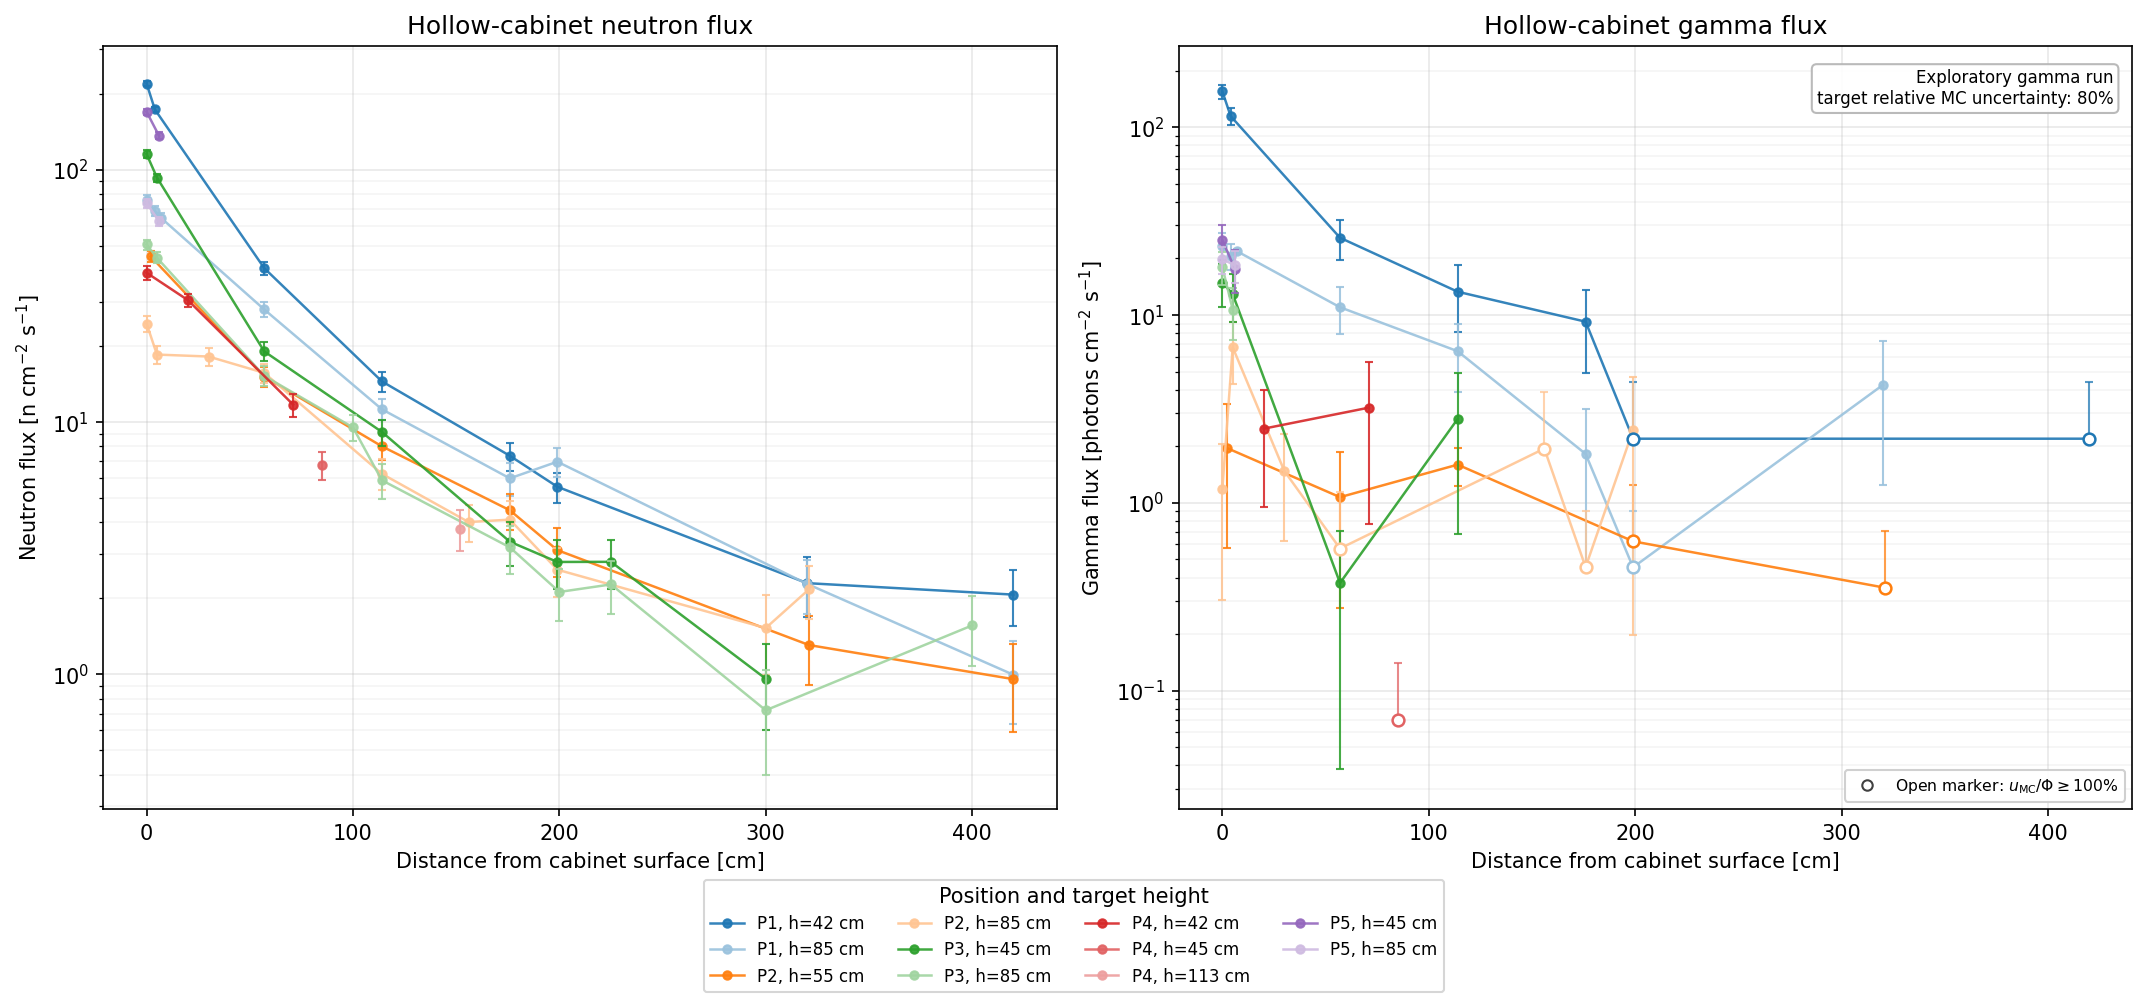

,dataset,ready,rows,path
0,neutron_flux,True,61,/root/Rfys_VI/RFP-master/Bachelor_projekt/NF_A...
1,gamma_flux,True,61,/root/Rfys_VI/RFP-master/Bachelor_projekt/NF_A...


,quantity,value
0,notebook,1H_F1_SIDES_AND_FRONT_F2_Hollow_cabinet_geo_+_...
1,geometry_mode,three hollow vertical walls; rear f2 solid
2,hollow_faces,"+x / front f2, -y / f1, +y / f1"
3,rear_f2_minus_x_layers_cm,15 solid steel
4,front_f2_plus_x_layers_cm,2 steel + 5 air + 8 steel
5,minus_y_f1_layers_cm,2 steel + 5 air + 6 steel
6,plus_y_f1_layers_cm,2 steel + 5 air + 6 steel
7,f3_bottom_cm,25.0
8,f4_top_cm,12.0
9,experiment_date,2026-03-15


In [29]:
from matplotlib.lines import Line2D
from matplotlib.colors import to_rgb


# ============================================================
# Colour configuration
# ============================================================

position_colors = {
    "P1": "tab:blue",
    "P2": "tab:orange",
    "P3": "tab:green",
    "P4": "tab:red",
    "P5": "tab:purple",
}


def lighten_color(color, fraction):
    """
    Blend a colour with white.

    Parameters
    ----------
    color
        Any Matplotlib-compatible colour.
    fraction : float
        0.0 gives the original colour, while increasing values
        produce progressively lighter colours.
    """
    rgb = np.asarray(
        to_rgb(color),
        dtype=float,
    )
    white = np.ones(3)

    return tuple(
        (1.0 - fraction) * rgb
        + fraction * white
    )


# Collect every target height present for each measurement position.
available_heights = {
    position: set()
    for position in position_colors
}

for table in (
    neutron_scan_summary,
    gamma_scan_summary,
):
    if table is None or table.empty:
        continue

    unique_position_heights = table[
        ["position", "height_cm"]
    ].drop_duplicates()

    for position, height_cm in (
        unique_position_heights.itertuples(
            index=False,
            name=None,
        )
    ):
        available_heights.setdefault(
            position,
            set(),
        ).add(
            int(round(float(height_cm)))
        )


# Construct a dark-to-light scale separately for each position.
#
# The lowest measurement height receives the darkest colour.
# The highest measurement height receives the lightest colour.
position_height_colors = {}

for position, heights in available_heights.items():
    sorted_heights = sorted(heights)

    if len(sorted_heights) == 0:
        continue

    if len(sorted_heights) == 1:
        lightening_fractions = np.array([0.0])
    else:
        lightening_fractions = np.linspace(
            0.0,
            0.55,
            len(sorted_heights),
        )

    for height_cm, fraction in zip(
        sorted_heights,
        lightening_fractions,
    ):
        position_height_colors[
            (position, height_cm)
        ] = lighten_color(
            position_colors[position],
            fraction,
        )


def get_curve_color(position, height_cm):
    """Return the position- and height-specific curve colour."""
    height_key = int(round(float(height_cm)))

    return position_height_colors.get(
        (position, height_key),
        position_colors.get(position, "0.4"),
    )


# ============================================================
# Diagnostic neutron and gamma figure
# ============================================================

diagnostic_figure, diagnostic_axes = plt.subplots(
    1,
    2,
    figsize=(14.2, 5.8),
    dpi=150,
    layout="constrained",
)

diagnostic_specs = [
    (
        diagnostic_axes[0],
        neutron_scan_summary,
        "flux_physical [n/cm2/s]",
        "u_mc_physical [n/cm2/s]",
        r"Neutron flux [n cm$^{-2}$ s$^{-1}$]",
        "Hollow-cabinet neutron flux",
        False,
    ),
    (
        diagnostic_axes[1],
        gamma_scan_summary,
        "gamma_flux_physical [photon/cm2/s]",
        "u_mc_physical [photon/cm2/s]",
        r"Gamma flux [photons cm$^{-2}$ s$^{-1}$]",
        "Hollow-cabinet gamma flux",
        True,
    ),
]

gamma_mean_values = []
gamma_upper_values = []
gamma_has_zero_crossing = False


for (
    axis,
    table,
    value_column,
    uncertainty_column,
    ylabel,
    title,
    is_gamma,
) in diagnostic_specs:

    if table is None or table.empty:
        axis.text(
            0.5,
            0.5,
            "Run not completed",
            transform=axis.transAxes,
            ha="center",
            va="center",
            fontsize=13,
        )
        axis.set_title(title)
        axis.set_axis_off()
        continue

    grouped_curves = table.groupby(
        ["position", "height_cm"],
        sort=True,
    )

    for (position, height_cm), curve in grouped_curves:
        curve = curve.sort_values(
            "distance_cm"
        )

        x = curve[
            "distance_cm"
        ].to_numpy(dtype=float)

        y = curve[
            value_column
        ].to_numpy(dtype=float)

        u = curve[
            uncertainty_column
        ].to_numpy(dtype=float)

        # A logarithmic axis can only display positive values.
        valid_flux = (
            np.isfinite(x)
            & np.isfinite(y)
            & (y > 0.0)
        )

        x = x[valid_flux]
        y = y[valid_flux]
        u = u[valid_flux]

        if len(x) == 0:
            continue

        color = get_curve_color(
            position,
            height_cm,
        )

        # Draw all curves using the same simple line and marker style.
        axis.plot(
            x,
            y,
            color=color,
            marker="o",
            markerfacecolor=color,
            markeredgecolor=color,
            markersize=4.0,
            linewidth=1.2,
            linestyle="-",
            alpha=0.90,
            label=(
                f"{position}, "
                f"h={height_cm:g} cm"
            ),
        )

        known_uncertainty = (
            np.isfinite(u)
            & (u >= 0.0)
        )

        if not is_gamma:
            # Ordinary symmetric uncertainties can be shown for
            # the neutron results.
            axis.errorbar(
                x[known_uncertainty],
                y[known_uncertainty],
                yerr=u[known_uncertainty],
                fmt="none",
                ecolor=color,
                elinewidth=1.0,
                capsize=2.0,
                alpha=0.88,
            )

        else:
            relative_uncertainty = np.full_like(
                y,
                np.nan,
                dtype=float,
            )

            relative_uncertainty[
                known_uncertainty
            ] = (
                u[known_uncertainty]
                / y[known_uncertainty]
            )

            # These uncertainty intervals remain completely positive:
            #
            # y - u > 0.
            log_safe = (
                known_uncertainty
                & (relative_uncertainty < 1.0)
            )

            axis.errorbar(
                x[log_safe],
                y[log_safe],
                yerr=u[log_safe],
                fmt="none",
                ecolor=color,
                elinewidth=1.0,
                capsize=2.0,
                alpha=0.88,
            )

            # If u >= y, the symmetric uncertainty interval crosses
            # zero and cannot be represented on a logarithmic axis.
            #
            # Only the upper part of the error bar is displayed.
            # The central value is marked by an open circle.
            crosses_zero = (
                known_uncertainty
                & (relative_uncertainty >= 1.0)
            )

            if np.any(crosses_zero):
                gamma_has_zero_crossing = True

                upper_only_yerr = np.vstack(
                    [
                        np.zeros(
                            np.count_nonzero(
                                crosses_zero
                            )
                        ),
                        u[crosses_zero],
                    ]
                )

                axis.errorbar(
                    x[crosses_zero],
                    y[crosses_zero],
                    yerr=upper_only_yerr,
                    fmt="none",
                    ecolor=color,
                    elinewidth=1.0,
                    capsize=2.0,
                    alpha=0.75,
                )

                axis.scatter(
                    x[crosses_zero],
                    y[crosses_zero],
                    s=32,
                    marker="o",
                    facecolors="white",
                    edgecolors=color,
                    linewidths=1.2,
                    zorder=4,
                )

            gamma_mean_values.extend(
                y.tolist()
            )

            upper_values = y.copy()

            upper_values[
                known_uncertainty
            ] += u[
                known_uncertainty
            ]

            gamma_upper_values.extend(
                upper_values[
                    np.isfinite(upper_values)
                ].tolist()
            )

    axis.set_yscale("log")

    axis.set_xlabel(
        "Distance from cabinet surface [cm]"
    )
    axis.set_ylabel(ylabel)
    axis.set_title(title)

    axis.grid(
        True,
        which="major",
        alpha=0.28,
    )
    axis.grid(
        True,
        which="minor",
        alpha=0.12,
    )


# ============================================================
# Gamma-axis limits
# ============================================================

if gamma_mean_values:
    gamma_mean_array = np.asarray(
        gamma_mean_values,
        dtype=float,
    )

    gamma_upper_array = np.asarray(
        gamma_upper_values,
        dtype=float,
    )

    gamma_ymin = (
        np.nanmin(gamma_mean_array)
        / 3.0
    )

    gamma_ymax = (
        np.nanmax(gamma_upper_array)
        * 1.6
    )

    diagnostic_axes[1].set_ylim(
        gamma_ymin,
        gamma_ymax,
    )


# ============================================================
# Gamma uncertainty explanation
# ============================================================

if gamma_has_zero_crossing:
    gamma_uncertainty_handle = Line2D(
        [],
        [],
        color="0.25",
        marker="o",
        markerfacecolor="white",
        markeredgecolor="0.25",
        linestyle="none",
        markersize=5,
        label=(
            r"Open marker: "
            r"$u_{\mathrm{MC}}/\Phi \geq 100\%$"
        ),
    )

    # Place the label on the lower-right side of the gamma panel.
    diagnostic_axes[1].legend(
        handles=[
            gamma_uncertainty_handle
        ],
        loc="lower right",
        fontsize=7.5,
        framealpha=0.92,
    )


# Mark the gamma simulation as exploratory.
diagnostic_axes[1].text(
    0.98,
    0.97,
    (
        "Exploratory gamma run\n"
        "target relative MC uncertainty: "
        f"{GROUP_1_TARGET_REL_ERR:.0%}"
    ),
    transform=diagnostic_axes[1].transAxes,
    ha="right",
    va="top",
    fontsize=8,
    bbox={
        "boxstyle": "round,pad=0.3",
        "facecolor": "white",
        "edgecolor": "0.7",
        "alpha": 0.90,
    },
)


# ============================================================
# Shared position and height legend
# ============================================================

handles, labels = (
    diagnostic_axes[0]
    .get_legend_handles_labels()
)

if not handles:
    handles, labels = (
        diagnostic_axes[1]
        .get_legend_handles_labels()
    )

if handles:
    diagnostic_figure.legend(
        handles,
        labels,
        loc="lower center",
        bbox_to_anchor=(
            0.5,
            -0.14,
        ),
        ncol=4,
        fontsize=8,
        title="Position and target height",
    )


# ============================================================
# Save the diagnostic figure
# ============================================================

diagnostic_png = (
    ROOT_FIGURE_DIR
    / "hollow_neutron_and_gamma_flux_diagnostics.png"
)

diagnostic_pdf = (
    ROOT_FIGURE_DIR
    / "hollow_neutron_and_gamma_flux_diagnostics.pdf"
)

diagnostic_figure.savefig(
    diagnostic_png,
    dpi=300,
    bbox_inches="tight",
)

diagnostic_figure.savefig(
    diagnostic_pdf,
    bbox_inches="tight",
)

plt.show()
plt.close(diagnostic_figure)


# ============================================================
# Transport handoff manifest
# ============================================================

handoff_df = pd.DataFrame(
    [
        {
            "dataset": "neutron_flux",
            "ready": (
                not neutron_scan_summary.empty
            ),
            "rows": len(
                neutron_scan_summary
            ),
            "path": str(
                NEUTRON_TABLE_DIR
                / (
                    "hollow_neutron_flux_"
                    "summary_final.csv"
                )
            ),
        },
        {
            "dataset": "gamma_flux",
            "ready": (
                not gamma_scan_summary.empty
            ),
            "rows": len(
                gamma_scan_summary
            ),
            "path": str(
                GAMMA_TABLE_DIR
                / (
                    "hollow_gamma_flux_"
                    "summary_final.csv"
                )
            ),
        },
    ]
)

handoff_df.to_csv(
    (
        ROOT_TABLE_DIR
        / "hollow_transport_handoff_manifest.csv"
    ),
    index=False,
)


# ============================================================
# Master metadata
# ============================================================

master_metadata_df = pd.DataFrame(
    [
        {
            "quantity": "notebook",
            "value": (
                "1H_F1_SIDES_AND_FRONT_F2_"
                "Hollow_cabinet_geo_+_n_and_g_runs.ipynb"
            ),
        },
        {
            "quantity": "geometry_mode",
            "value": (
                "three hollow vertical walls; "
                "rear f2 solid"
            ),
        },
        {
            "quantity": "hollow_faces",
            "value": (
                "+x / front f2, "
                "-y / f1, +y / f1"
            ),
        },
        {
            "quantity": "rear_f2_minus_x_layers_cm",
            "value": "15 solid steel",
        },
        {
            "quantity": "front_f2_plus_x_layers_cm",
            "value": (
                "2 steel + 5 air + 8 steel"
            ),
        },
        {
            "quantity": "minus_y_f1_layers_cm",
            "value": (
                "2 steel + 5 air + 6 steel"
            ),
        },
        {
            "quantity": "plus_y_f1_layers_cm",
            "value": (
                "2 steel + 5 air + 6 steel"
            ),
        },
        {
            "quantity": "f3_bottom_cm",
            "value": 25.0,
        },
        {
            "quantity": "f4_top_cm",
            "value": 12.0,
        },
        {
            "quantity": "experiment_date",
            "value": EXPERIMENT_DATE,
        },
        {
            "quantity": "neutron_transport_ready",
            "value": (
                not neutron_scan_summary.empty
            ),
        },
        {
            "quantity": "gamma_transport_ready",
            "value": (
                not gamma_scan_summary.empty
            ),
        },
        {
            "quantity": "neutron_gamma_combination",
            "value": (
                "not combined at flux level; "
                "convert separately to dose "
                "in Notebook 2H"
            ),
        },
        {
            "quantity": "gamma_target_relative_mc_uncertainty",
            "value": GROUP_1_TARGET_REL_ERR,
        },
        {
            "quantity": "gamma_run_status",
            "value": (
                "exploratory; not intended as "
                "final high-precision production result"
            ),
        },
    ]
)

master_metadata_df.to_csv(
    (
        ROOT_METADATA_DIR
        / "hollow_transport_master_metadata.csv"
    ),
    index=False,
)


display(handoff_df)
display(master_metadata_df)

# 7) Summary

Notebook 1H defines one fixed asymmetric hollow cabinet geometry and uses
it for both particle transports. The front (+x) f2 wall contains the 2 cm
steel + 5 cm air + 8 cm steel stack, and both f1/y walls contain the 2 cm
steel + 5 cm air + 6 cm steel stack. Only the rear (-x) f2 wall remains
15 cm solid steel; the 25 cm bottom and 12 cm top also remain solid. The
original inner cavity and outer cabinet surfaces are preserved.

The neutron result is scaled with the source-specific neutron emission at
the selected experimental date. The photon result uses the independent
ALPHANSO line distribution and gamma-to-neutron yield ratio. The exported
statistical uncertainties are OpenMC batch uncertainties only; they do not
cover source-certificate, ALPHANSO, geometry, material, nuclear-data,
positioning, or detector-response uncertainty.

The two final flux files are the only production inputs required by
`2H_Hollow_cabinet_unified.ipynb`. They must not be added directly.
